In [2]:
import os
import re
import pickle
from wordcloud import WordCloud
import numpy as np
import seaborn as sns
import nibabel as nib
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.ticker import FuncFormatter

In [3]:
# read in atlases
# atlas_base_path = "/home/zachkaras/fmri/fmri_model/analysis/pipeline/atlases"
atlas_base_path = "/home/zachkaras/fmri_model/analysis/pipeline/atlases"

# read in 2d mni mask
mask = nib.load(f"{atlas_base_path}/MNI152_T1_2mm_brain_mask.nii.gz")
og_shape = mask.shape
mask = mask.get_fdata().flatten()
brain_idx = np.where(mask>0)[0]

atlas = nib.load(f"{atlas_base_path}/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_2mm.nii.gz")
atlas_vec = atlas.get_fdata().flatten()
atlas_only_brain = atlas_vec[brain_idx] # contains the schaefer parcel numbers
cortex_vx = np.where(atlas_only_brain != 0)[0]
parcel_nums = atlas_only_brain[cortex_vx]

# Making empty templates to save output
empty_schaefer = np.zeros(atlas_only_brain.shape)
empty_mni = np.zeros(atlas_vec.shape)


In [4]:
class Regression_Info(object):
    # [model_name, task, look_ahead, n_delays, layer, stat]
    def __init__(self, model_name=None, task=None, look_ahead=None, n_delays=None, layer=None, stat=None):
        self.model_name = model_name
        self.task       = task
        self.look_ahead = look_ahead
        self.n_delays   = n_delays
        self.layer      = layer
        self.stat       = stat
        
    def __str__(self):
        return f"{self.model_name}, {self.task}, {self.look_ahead}, {self.n_delays}, {self.layer}, {self.stat}"

def nested_dict():
        return defaultdict(nested_dict)

def convert_to_nifti(values):
    # working backwards to save correlation values as voxels in MNI space
    empty_schaefer[cortex_vx] = values
    empty_mni[brain_idx] = empty_schaefer
    result_brain = np.reshape(empty_mni, og_shape)

    # Saving results
    nifti_result = nib.Nifti1Image(result_brain, affine=atlas.affine, header=atlas.header)
    nib.save(nifti_result, "test_plotting.nii.gz")
    return result_brain, nifti_result


def parse_regression_info(path):
    
    parts = path.split('-') 
    # example: ['codegemma_7b', 'code', 'look_ahead_by_1', 'ndelays_0', 'layer_28', 'correlations.pkl']
    info = Regression_Info()
    info.model_name = parts[0]
    info.task       = parts[1]
    info.look_ahead = parts[2]
    info.n_delays   = parts[3]
    info.layer      = parts[4]
    info.stat       = (parts[5])[:-4]
    
    return info


def find_cutoff(vec, threshold = 10**4):
    
    # I can find the threshold point based on sorting, then keep everything in the same place
    copy = vec.copy()
    copy.sort()
    cutoff = copy[-threshold-1]
    return cutoff


def iterate_through_participants(filepath, stat):
    participants = os.listdir(filepath)
    
    stat_collection = nested_dict()
    parcel_collection = nested_dict()
    
    # iterating through participants
    for p in participants:
        print(p)
        datapath = f"{filepath}/{p}"
        files = os.listdir(datapath)
        stat_files = [f for f in files if re.search(stat, f)]
        
        # iterating through the stat files
        # these are vectors of correlation coefficients between predicted and recorded signal
        # Different parameters were adjusted, so the folder contains all the possibilities
        # [model_name, task, look_ahead, n_delays, layer, stat]
        for sf in stat_files:
            
            info = parse_regression_info(sf)
            
            stat_file = f"{datapath}/{sf}"
            with open(stat_file, 'rb') as f:
                try:
                    stat_vec = pickle.load(f)
                except:
                    print(f"issue with {p}: {sf}")
            
            
            # filter to top 10k, 10k is default parameter but can be changed with threshold argument
            cutoff = find_cutoff(stat_vec)
            # print(len(stat_vec))
            top_voxel_idx = (np.where(stat_vec > cutoff))[0]
            top_voxel_vals = stat_vec[top_voxel_idx]
            top_parcels = parcel_nums[top_voxel_idx]
            top_parcels = [int(parcel) for parcel in top_parcels]
            
            # print(len(top_voxel_vals), top_voxel_vals)
            # plt.hist(top_parcels, bins=400)
            # plt.title("Schaefer Parcel Numbers for top 10K voxels")
            # top_parcels = [f"p{str(p)[:-2]}" for p in top_parcels]
            # parcel_string = " ".join(top_parcels)
            # print(parcel_string)
            # print(top_parcels)
            # wc = WordCloud(width=800,height=400, background_color="white").generate(parcel_string)
            # plt.figure()
            # plt.imshow(wc)
            # plt.show()
            # save into big dictionary structure
            # 6 figures, one for each model
            # in 2 rows, one for each task
            
            # Should I keep one thing consistent, like only look at the best layer for a given model
            # and only the best performing participants?
            # It should depend on the research questions...
            # No I'd like to see across a range of participants
            # I feel like layer 
            parcel_collection[p][info.task][info.model_name][info.n_delays][info.look_ahead][info.layer] = top_parcels
            
            if info.look_ahead not in stat_collection[info.task][info.model_name][info.n_delays].keys():
                stat_collection[info.task][info.model_name][info.n_delays][info.look_ahead]  = top_voxel_vals
            else:
                np.append(stat_collection[info.task][info.model_name][info.n_delays][info.look_ahead], top_voxel_vals)
                # np.append(parcel_collection[p][info.task][info.model_name][info.n_delays][info.look_ahead][info.layer], top_parcels)
            # print(stat_vec)
            # break
        # break
    
    return stat_collection, parcel_collection
        
        

In [5]:
# iterate through directories, parse the file names, and accumulate stats

# parsing file names [model_name, task, look_ahead, n_delays, layer, stat]
# filepath = "/storage1/fmri_model_data/ridge_regression_pca_params"
filepath = "/data/zachkaras/fmri_model_data/ridge_regression_pca_params"
stat_collection, parcel_collection = iterate_through_participants(filepath, 'correlations')



111
117
203
204
129
134
144
133
109
142
150
112
122
141
101
125
108
105
119
121
118
138
151
130
201


In [6]:
with open("top_parcels.pkl", 'wb') as f:
    pickle.dump(parcel_collection, f) # TODO

In [ ]:
with open("top_parcels.pkl", 'rb') as f:
    parcel_collection = pickle.load(f)

ndelays_0 look_ahead_by_0
ndelays_0 look_ahead_by_1
ndelays_0 look_ahead_by_3
ndelays_0 look_ahead_by_5
ndelays_0 look_ahead_by_10
ndelays_4 look_ahead_by_0
ndelays_4 look_ahead_by_1
ndelays_4 look_ahead_by_3
ndelays_4 look_ahead_by_5
ndelays_4 look_ahead_by_10
ndelays_10 look_ahead_by_0
ndelays_10 look_ahead_by_1
ndelays_10 look_ahead_by_3
ndelays_10 look_ahead_by_5
ndelays_10 look_ahead_by_10
ndelays_16 look_ahead_by_0
ndelays_16 look_ahead_by_1
ndelays_16 look_ahead_by_3
ndelays_16 look_ahead_by_5
ndelays_16 look_ahead_by_10
ndelays_20 look_ahead_by_0
ndelays_20 look_ahead_by_1
ndelays_20 look_ahead_by_3
ndelays_20 look_ahead_by_5
ndelays_20 look_ahead_by_10
ndelays_0 look_ahead_by_0
ndelays_0 look_ahead_by_1
ndelays_0 look_ahead_by_3
ndelays_0 look_ahead_by_5
ndelays_0 look_ahead_by_10
ndelays_4 look_ahead_by_0
ndelays_4 look_ahead_by_1
ndelays_4 look_ahead_by_3
ndelays_4 look_ahead_by_5
ndelays_4 look_ahead_by_10
ndelays_10 look_ahead_by_0
ndelays_10 look_ahead_by_1
ndelays_10 loo

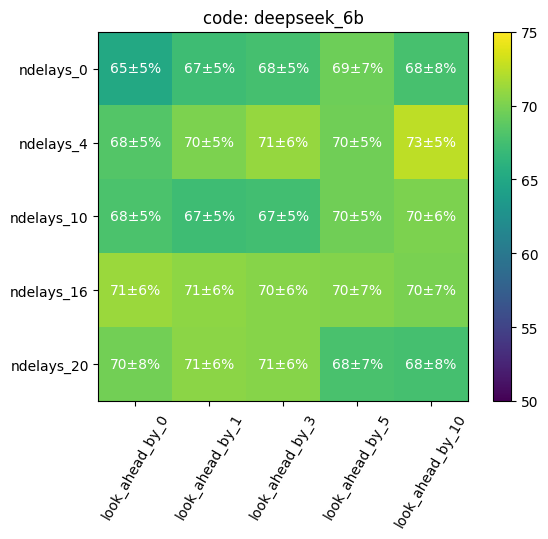

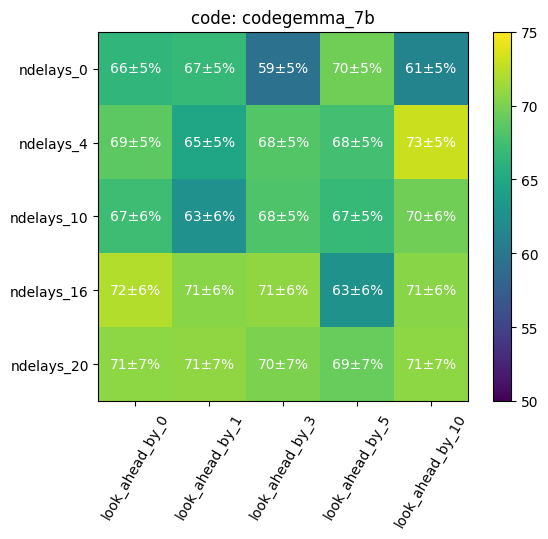

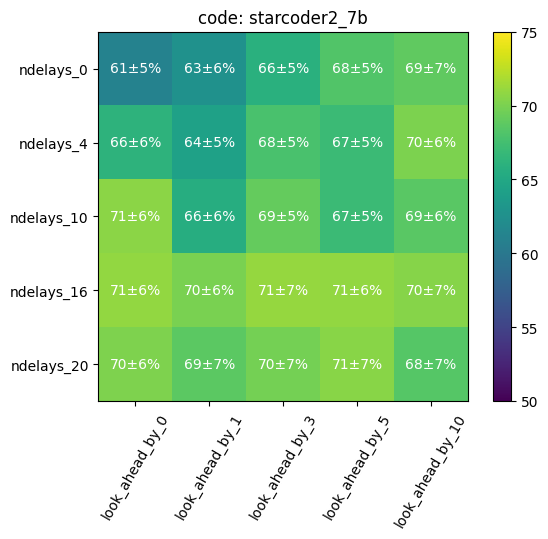

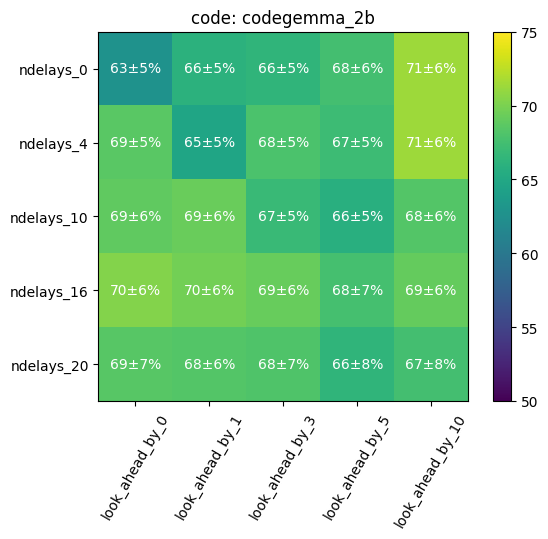

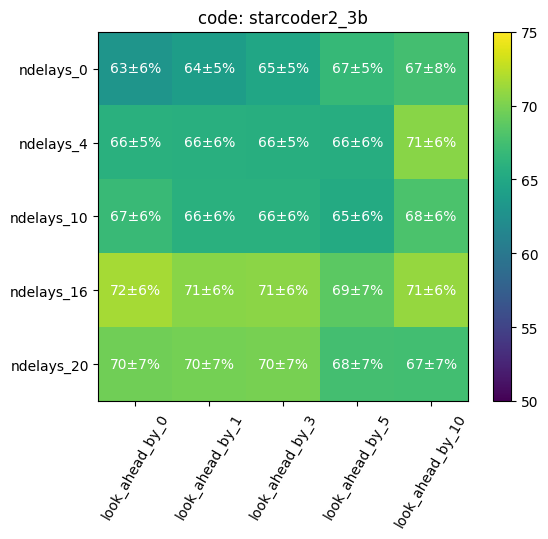

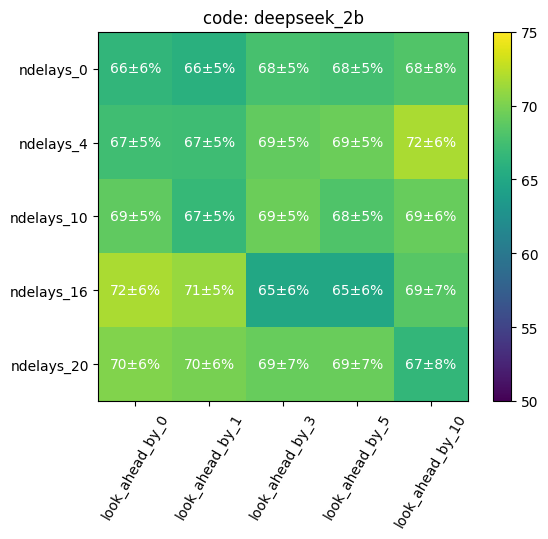

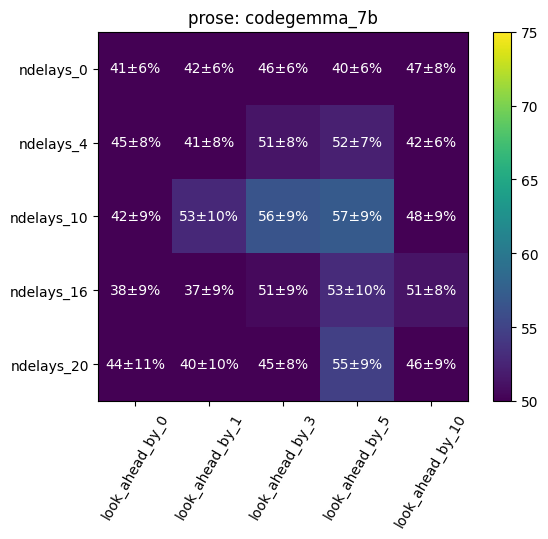

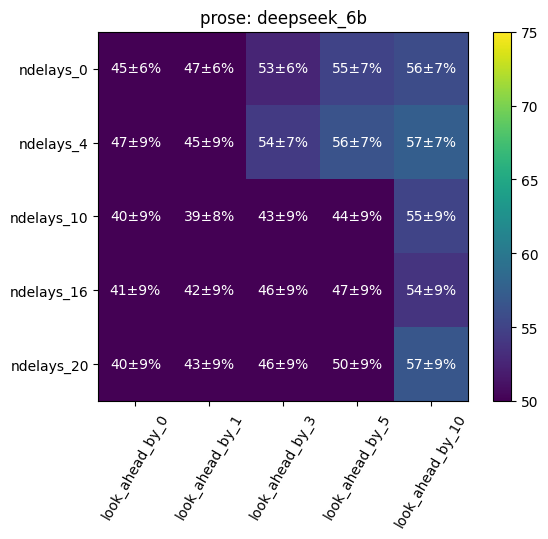

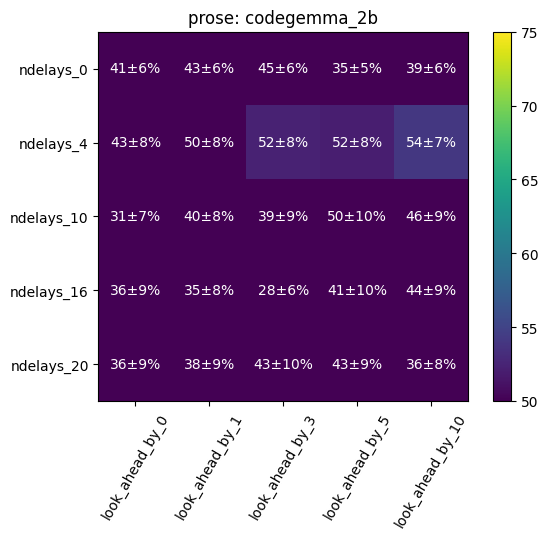

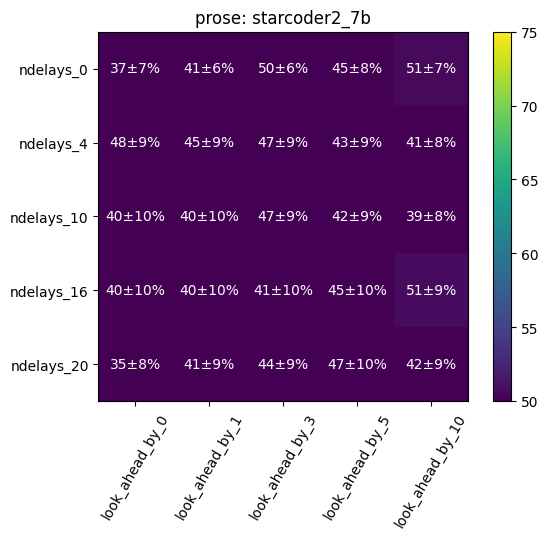

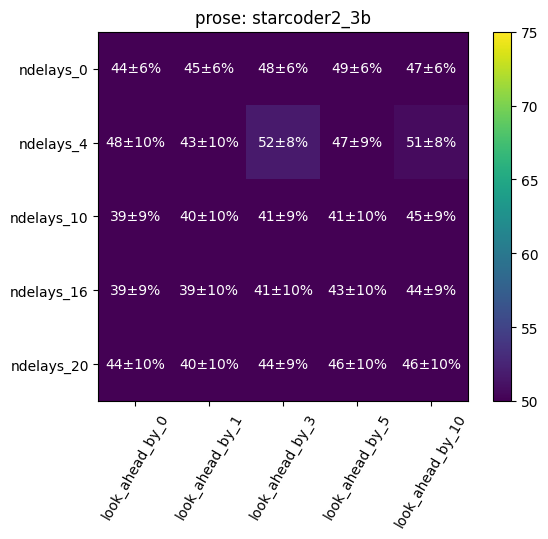

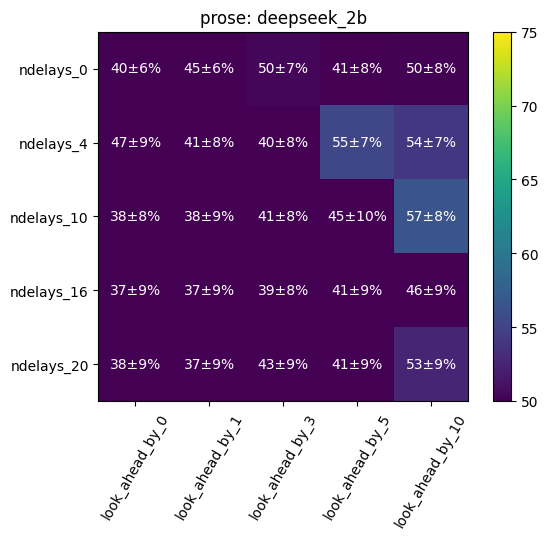

In [7]:
# EXAMPLE: stat_collection[info.task][info.model_name][info.n_delays][info.look_ahead]
# need to iterate through dictionary structure

# param_ave = nested_dict()

for task, model_delay_peek_vals in stat_collection.items():
    for model, delay_peek_vals in model_delay_peek_vals.items():
        param_delays = []
        delay_stds = []
        delay_nums = [0,4,10,16,20]
        delay_labels = [f"ndelays_{d}" for d in delay_nums]
        for dl in delay_labels:
            # print(dl)
            peek_vals = delay_peek_vals[dl]
            peek_nums = [0,1,3,5,10]
            peek_labels = [f'look_ahead_by_{p}' for p in peek_nums]
            
            param_averages = []
            param_stds = []
            for pl in peek_labels:
                print(dl, pl)
                vals = peek_vals[pl]
                std = np.std(vals)
                ave = np.mean(vals)
                param_averages.append(ave)
                param_stds.append(std)
            param_delays.append(param_averages)
            delay_stds.append(param_stds)

        fig, ax = plt.subplots()
        
        im = ax.imshow(param_delays, vmin=0.5, vmax=0.75)
        ax.set_xticks(ticks=range(0,5), labels=peek_labels, rotation=60)
        ax.set_yticks(ticks=range(0,5), labels=delay_labels)
        
        for i in range(len(delay_labels)):
            for j in range(len(peek_labels)):
                text = ax.text(j, i, f"{(param_delays[i][j])*100:.0f}\u00B1{(delay_stds[i][j])*100:.0f}%",
                       ha="center", va="center", color="w")
        
        cbar = fig.colorbar(im, ax=ax)
        cbar.ax.yaxis.set_major_formatter(
            FuncFormatter(lambda x, pos: f"{x*100:.0f}")
        )
        title = f"{task}: {model}"
        ax.set_title(title)
        plt.savefig(f"results/UPDATED_022026-{task}-{model}-heatmap.png", dpi=150)
        
    #     break
    # break

        

In [8]:
# plot
# for task, model_delay_peek_vals in param_ave.items():
#     for model, delay_peek_vals in model_delay_peek_vals.items():
#         for delay, peek_vals in delay_peek_vals.items():
#             for peek, vals in peek_vals.items():
#                 delays = delay_peek_vals.keys()
#                 peeks = peek_vals.keys()
#                 print(delays, peeks)
#                 print(peek_vals.values())
#             break
#         break
#     break
    

In [9]:
# iterate through parcel_collection
# participant, task, model name, delays, look ahead, layer

# For a given participant, iterate through 

# I'd like to plot all 8 layers for a given participant for a given model, for a given look ahead, for a given delay
best_models = ['code-deepseek_6b-ndelays_4-look_ahead_by_10', 
               'code-codegemma_7b-ndelays_4-look_ahead_by_10',
               'code-codegemma_7b-ndelays_16-look_ahead_by_0', 
               'prose-codegemma_7b-ndelays_10-look_ahead_by_5', 
               'prose-deepseek_6b-ndelays_20-look_ahead_by_10']

# Maybe a really good participant and a mediocre participant
# Good - 121
# Med. - 150
# bad  - 144
key_participants = ['144', '121', '150']
for m in best_models:
    # print(m)
    parts = m.split('-')
    task,model,delays,look_ahead = parts[0],parts[1],parts[2],parts[3]

    for vip in key_participants:
        # print(vip, task, model, delays, look_ahead)
        # print(parcel_collection[vip][task][model][delays][look_ahead]['layer_0'])
        top_parcels = parcel_collection[vip][task][model][delays][look_ahead]
        
        # wrap this for loop in a plot to collect the different histograms
        # plt.figure(figsize=(10,6))
        # bins = 400

        # for layer,vals in top_parcels.items():
        #     # 
        #     # plt.hist(vals, bins=bins, alpha=0.35, density=False)
        #     plt.hist(vals, bins=bins, histtype='step', density=True)
        # plt.legend(list(top_parcels.keys()))
        # plt.show()
    # break
            
    


In [10]:
"""
Overlapping Histogram — largest bar drawn first (behind), smaller bars in front.
For each bin, each layer draws from 0 to its own count (no stacking).
Accepts data as: {'label_1': [...], 'label_2': [...], ...}
Values should be integers in range 1-400.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
import seaborn as sns

with open("schaefer_parcel_counts.pkl", 'rb') as f:
    parcel_voxel_counts = pickle.load(f)

# ── Configuration ────────────────────────────────────────────────────────────

NUM_BINS = 200          # number of histogram bins
VALUE_MIN = 1          # minimum possible value in data
VALUE_MAX = 400        # maximum possible value in data
FIGSIZE = (14, 6)      # figure dimensions (width, height)
CHART_TITLE = "Group Distribution"

# ─────────────────────────────────────────────────────────────────────────────


def build_histogram(data: dict, num_bins: int, vmin: int, vmax: int) -> tuple:
    """
    Returns:
        bin_edges  : array of length num_bins + 1
        counts     : dict {label: array of length num_bins}
    """
    def calculate_voxel_proportion(num, idx):
        total_vx_count = parcel_voxel_counts[idx+1]
        proportion = num/total_vx_count
        return proportion

    bin_edges = np.linspace(vmin, vmax + 1, num_bins + 1)
    counts = {}
    for label, values in data.items():
        hist, _ = np.histogram(values, bins=bin_edges)
        ratios = [calculate_voxel_proportion(n, i) for i,n in enumerate(hist)]
        counts[label] = ratios
    return bin_edges, counts


def plot_histogram(data: dict, num_bins: int = NUM_BINS,
                   vmin: int = VALUE_MIN, vmax: int = VALUE_MAX,
                   title: str = CHART_TITLE, figsize: tuple = FIGSIZE,
                   region_boundaries=None):
    """
    region_boundaries: list of (start_pos, end_pos, region_number) tuples.
      If provided, a horizontal line spans each region at two alternating
      offsets below the x-axis, with the region number centered on the line.
    """

    bin_edges, counts = build_histogram(data, num_bins, vmin, vmax)
    labels = list(counts.keys())
    n_bins = num_bins
    bin_width = bin_edges[1] - bin_edges[0]
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    sns.set_theme(style="ticks", context="talk")
    palette = sns.color_palette("rainbow", len(labels))

    sorted_labels = sorted(labels, key=lambda lbl: int(lbl.split("_")[-1]))
    label_color = {lbl: palette[i] for i, lbl in enumerate(sorted_labels)}

    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(axis="y", linewidth=0.8, linestyle="--", zorder=0)
    ax.grid(axis="x", visible=False)

    # ── Per-bin overlapping bars ──────────────────────────────────────────────
    for b in range(n_bins):
        sorted_by_count = sorted(labels, key=lambda lbl: counts[lbl][b], reverse=True)
        sorted_by_count = sorted_by_count[:2]

        for lbl in sorted_by_count:
            val = counts[lbl][b]
            if val == 0:
                continue
            ax.bar(
                bin_centers[b],
                val,
                width=bin_width * 0.92,
                bottom=0,
                color=label_color[lbl],
                edgecolor="#2d2d4c",
                linewidth=0.4,
                zorder=2,
            )

    # ── Axes styling ──────────────────────────────────────────────────────────
    ax.set_title(title, fontsize=16, fontweight="bold", pad=16, loc="left")
    ax.set_xlabel("Cortical Region", color="#7070a0", fontsize=11, labelpad=45)
    ax.set_ylabel("Proportion of Top Voxels in Schaefer Parcel", color="#7070a0", fontsize=11, labelpad=8)
    ax.set_ylim([0.0, 1.0])
    ax.tick_params(axis='y', colors="#5a5a8a", labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # ── X-axis: horizontal region lines and numbers ───────────────────────────
    if region_boundaries is not None:
        ax.set_xticks([])

        # x in data coords, y in axes fraction (0 = plot bottom)
        base_trans = ax.get_xaxis_transform()
        # Two alternating y-offsets in points
        line_offsets_pts = [-5, -25]
        num_offsets_pts  = [-10, -31]

        for i, (start, end, num) in enumerate(region_boundaries):
            line_y = line_offsets_pts[i % 2]
            num_y  = num_offsets_pts[i % 2]
            mid    = (start + end + 1) / 2

            # Horizontal line spanning the region
            line_trans = mtransforms.offset_copy(base_trans, fig=fig, x=0, y=line_y, units='points')
            ax.plot([start, end + 1], [0, 0], color="#5a5a8a", linewidth=1,
                    transform=line_trans, clip_on=False)

            # Region number centered on the line
            ax.annotate(
                str(num),
                xy=(mid, 0), xycoords=('data', 'axes fraction'),
                xytext=(0, num_y), textcoords='offset points',
                ha='center', va='top', fontsize=10, color="#5a5a8a",
                clip_on=False,
            )
    else:
        tick_step = max(1, n_bins // 8)
        tick_positions = bin_edges[::tick_step]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels([f"{int(v)}" for v in tick_positions], color="#5a5a8a")
        ax.tick_params(axis='x', colors="#5a5a8a", labelsize=9)

    # ── Legend (in sorted layer order) ───────────────────────────────────────
    legend_patches = [
        mpatches.Patch(color=label_color[lbl], label=lbl)
        for lbl in sorted_labels
    ]
    ax.legend(
        handles=legend_patches,
        loc="best",
        frameon=True,
        framealpha=0.15,
        edgecolor="#2a2a4a",
        fontsize=9,
        ncol=2,
    )

    plt.tight_layout()
    plt.savefig("histogram_output.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()


In [11]:
with open('/home/zachkaras/fmri_model/analysis/fir/schaefer_parcel_labels.pkl', 'rb') as f:
    schaefer_parcel_labels = pickle.load(f)


def compute_region_boundaries(hemi_order, parcel_labels):
    """
    Returns a list of (start_pos, end_pos, region_number) tuples,
    one per unique HO cortical region, in the order they appear on the x-axis.
    """
    boundaries = []
    current_region = None
    start_pos = 0
    region_num = 1
    for i, p in enumerate(hemi_order):
        region = parcel_labels[p]
        if region != current_region:
            if current_region is not None:
                boundaries.append((start_pos, i - 1, region_num))
                region_num += 1
            current_region = region
            start_pos = i
    boundaries.append((start_pos, len(hemi_order) - 1, region_num))
    return boundaries

def plot_top_parcels(top_parcels, participant, model):
    for hemi in ['left', 'right']:
        hemi_order = list(schaefer_parcel_labels[hemi].keys())
        pos_map = {p: i for i, p in enumerate(hemi_order)}

        remapped = {
            layer: [pos_map[v] for v in vals if v in pos_map]
            for layer, vals in top_parcels.items()
        }

        region_boundaries = compute_region_boundaries(hemi_order, schaefer_parcel_labels[hemi])

        # Print the region number → name mapping for reference
        region_names = {}
        current_region = None
        region_num = 1
        for p in hemi_order:
            region = schaefer_parcel_labels[hemi][p]
            if region != current_region:
                region_names[region_num] = region
                current_region = region
                region_num += 1
        # print(f"\n{hemi} hemisphere region legend:")
        # for num, name in region_names.items():
        #     print(f"  {num}: {name}")

        plot_histogram(remapped, num_bins=len(hemi_order), vmin=0, vmax=len(hemi_order) - 1,
                    title=f"{participant}-{model}\n{hemi} hemisphere", region_boundaries=region_boundaries)


In [12]:
len(set(schaefer_parcel_labels['right'].values()))

46

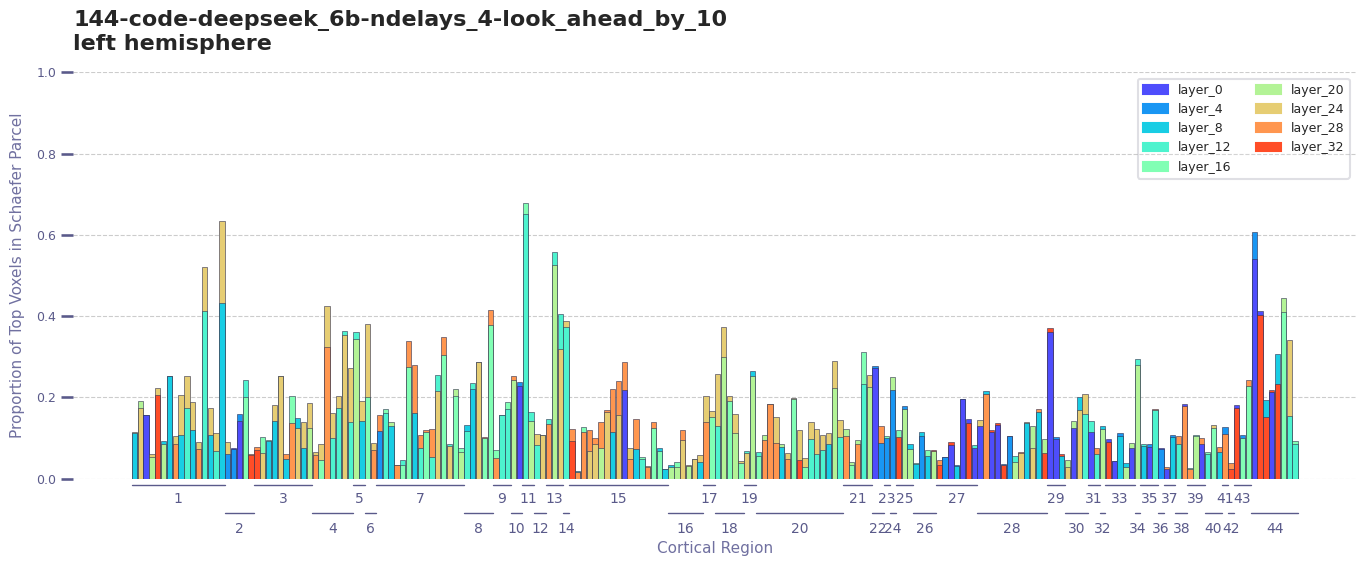

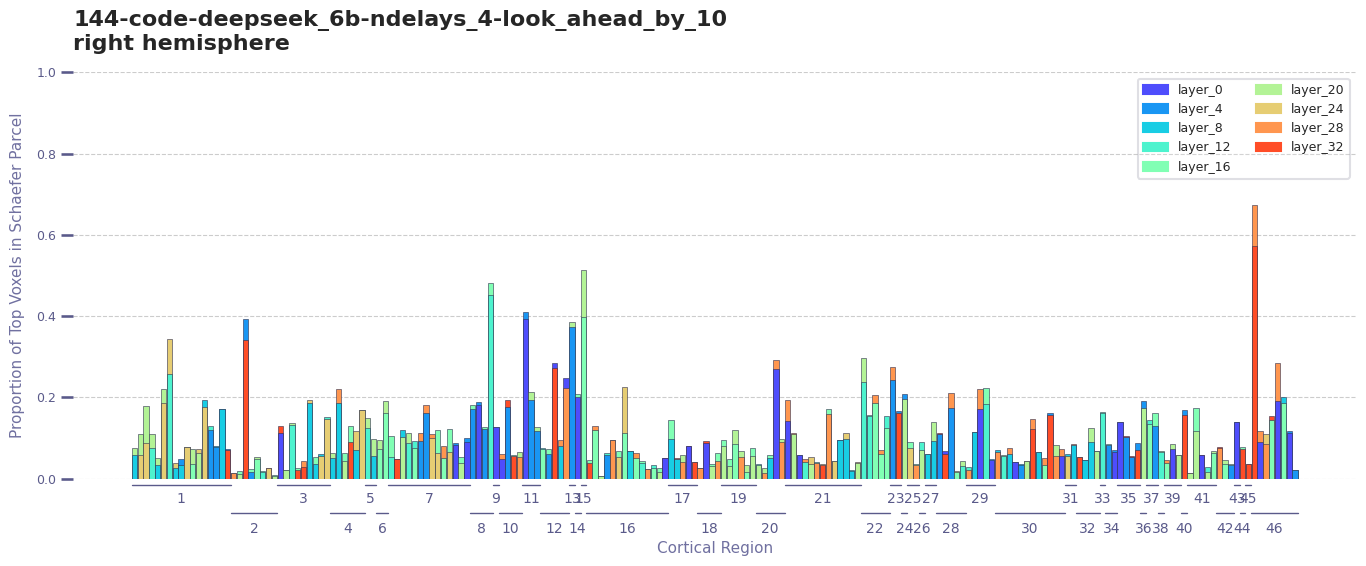

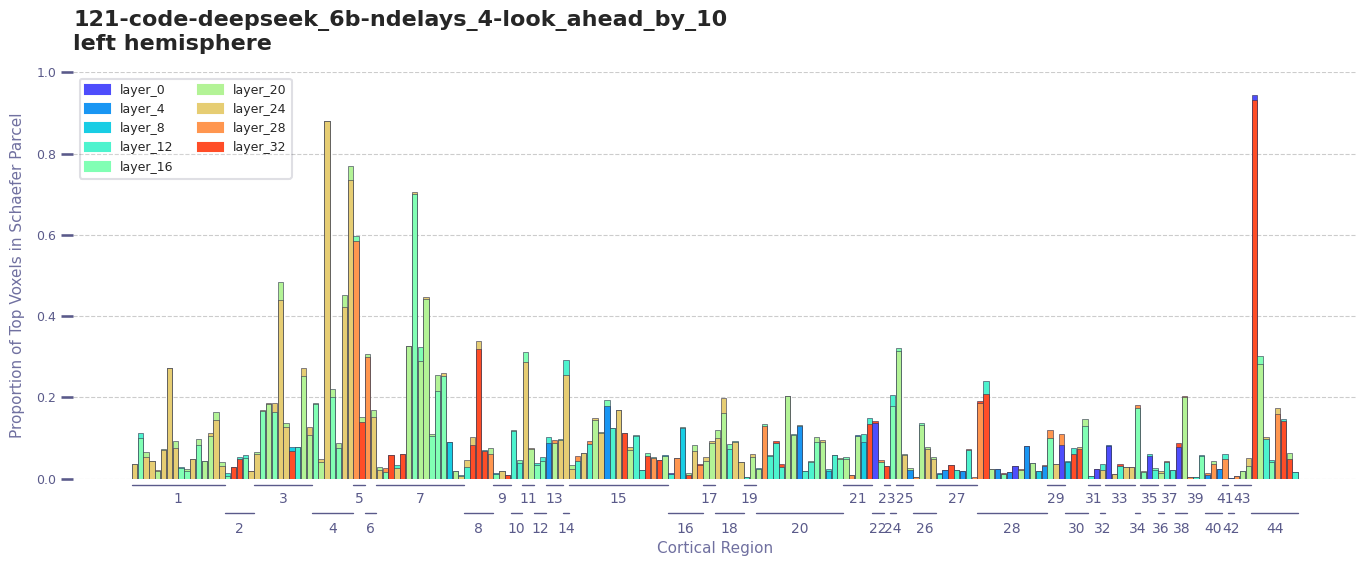

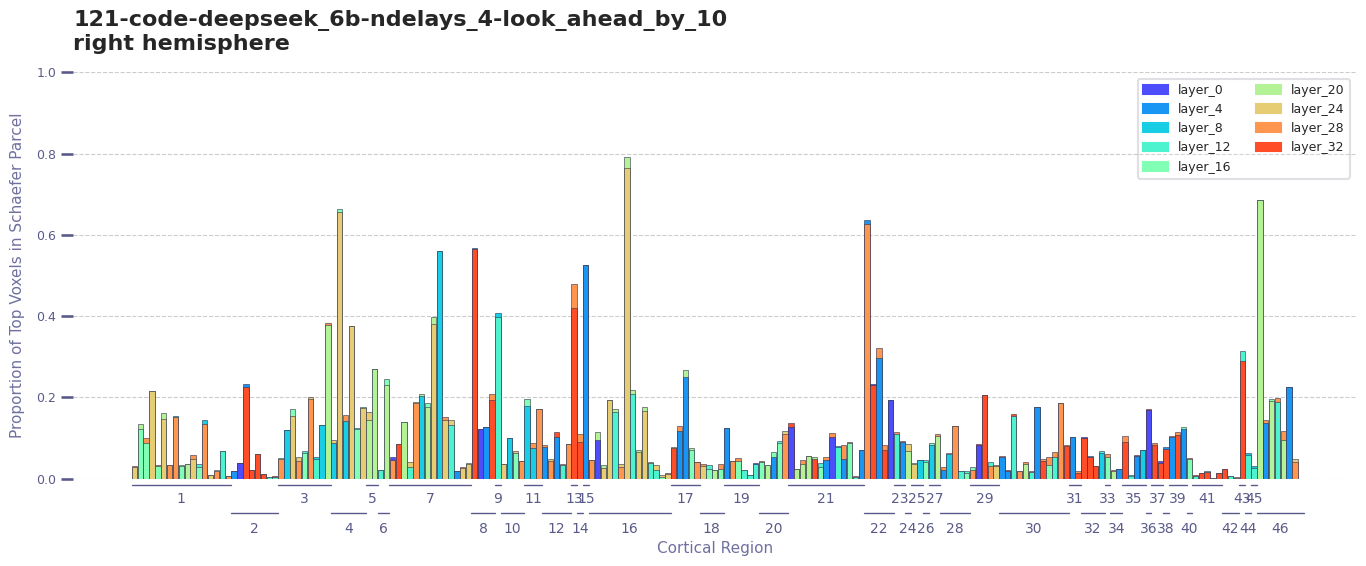

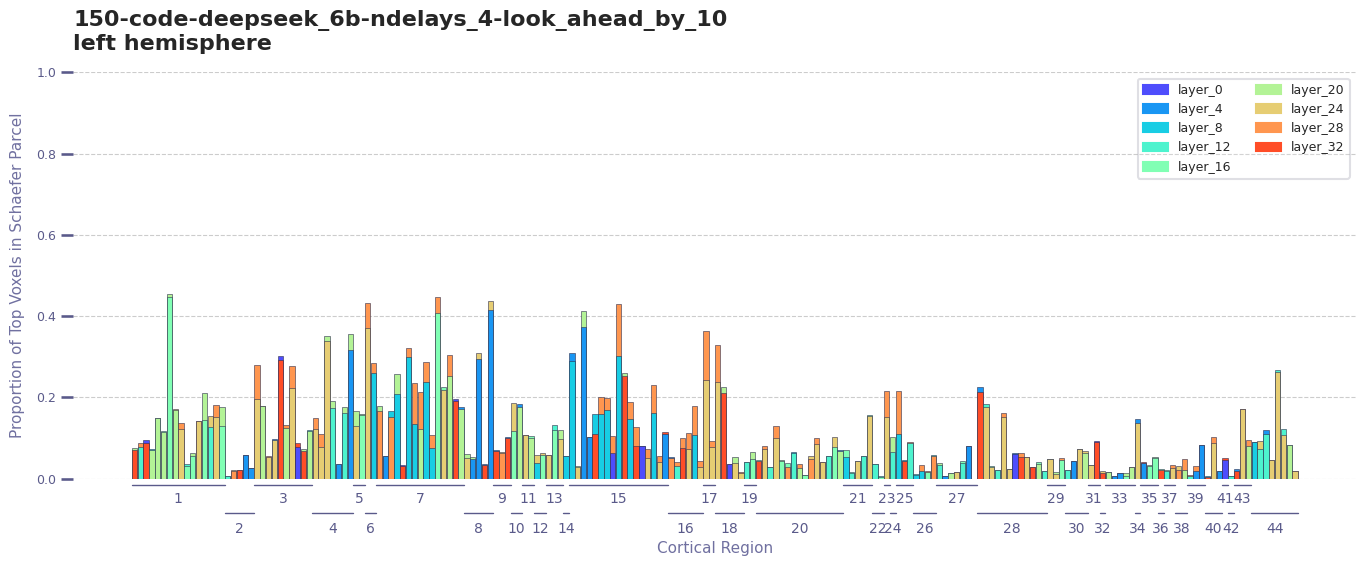

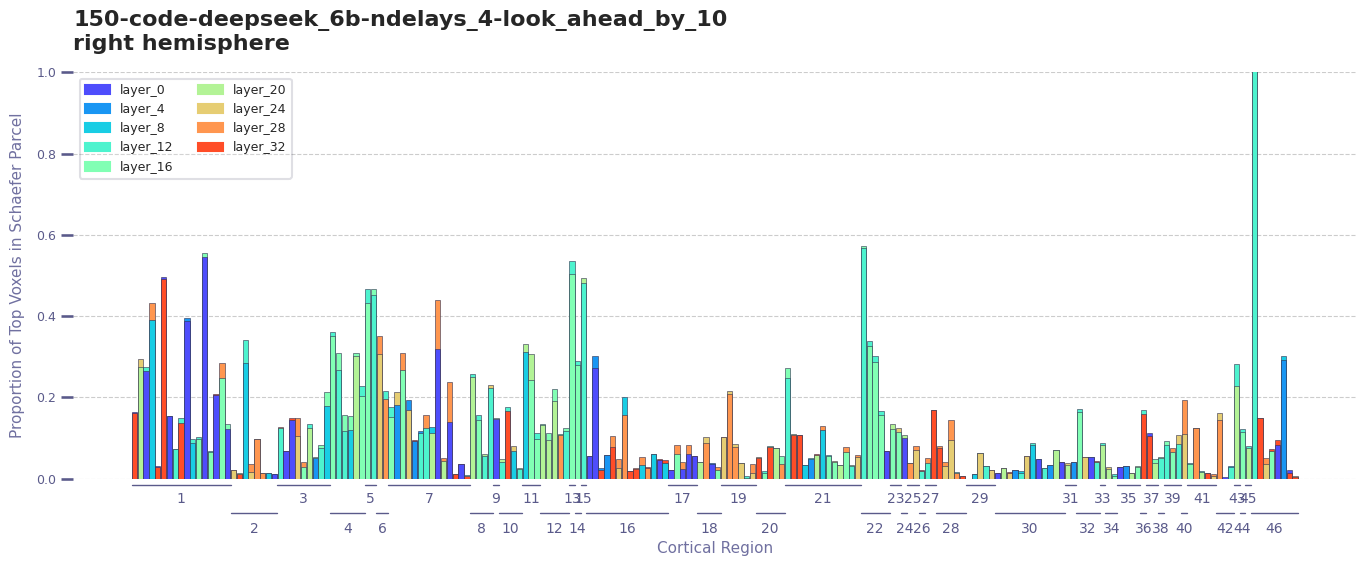

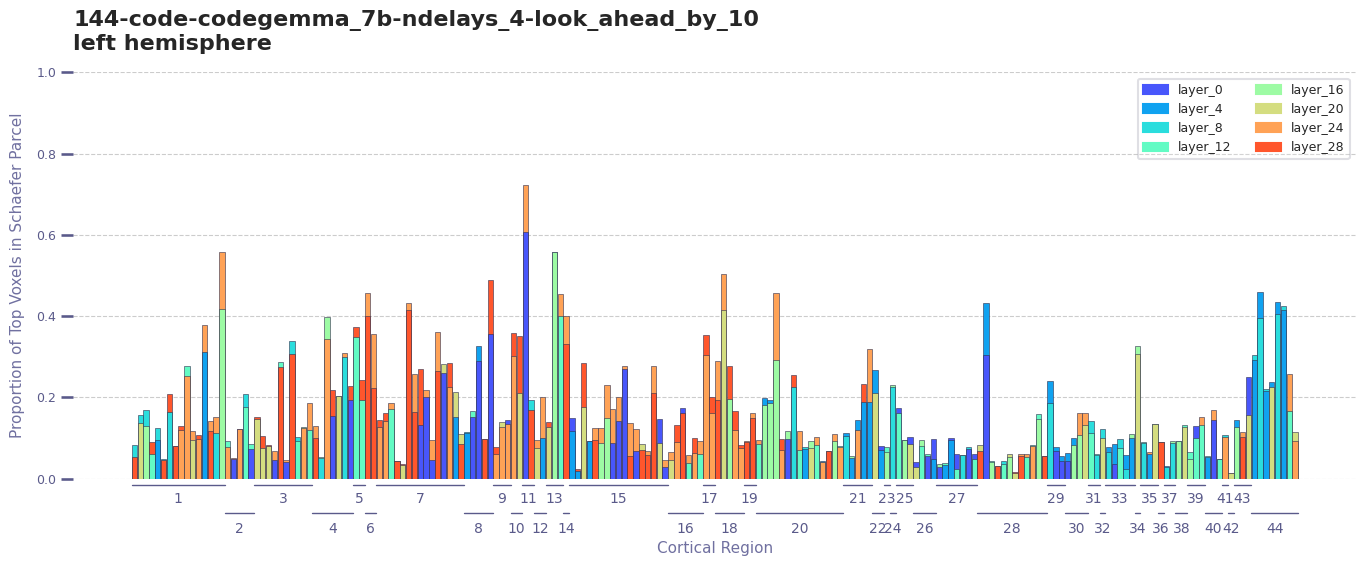

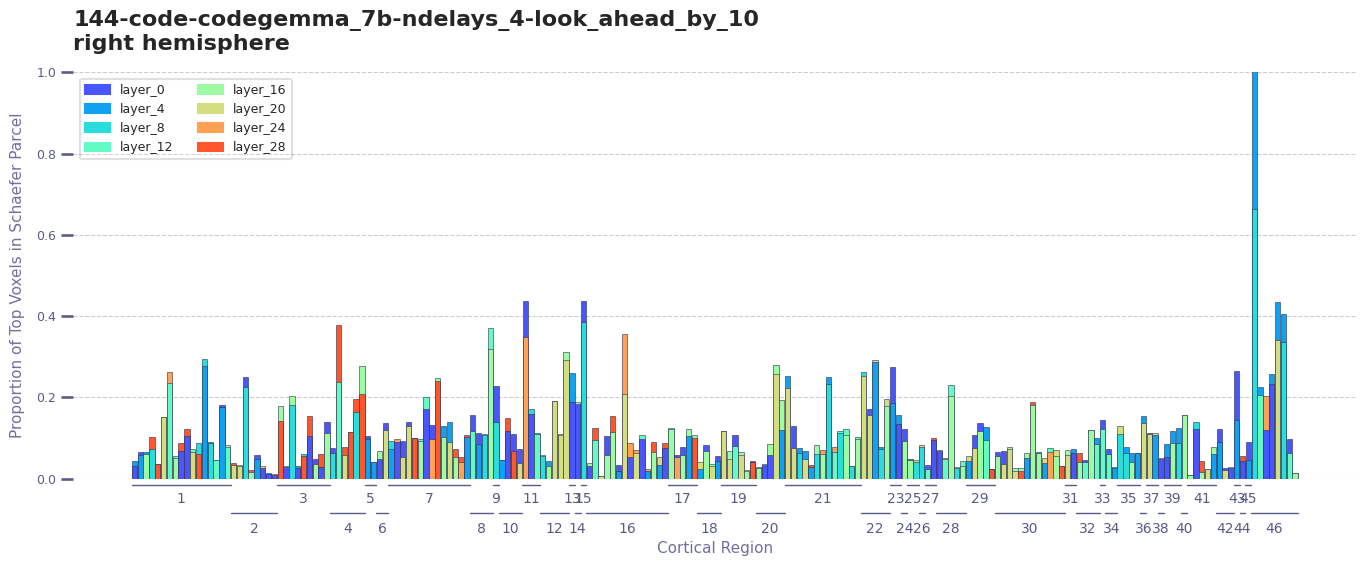

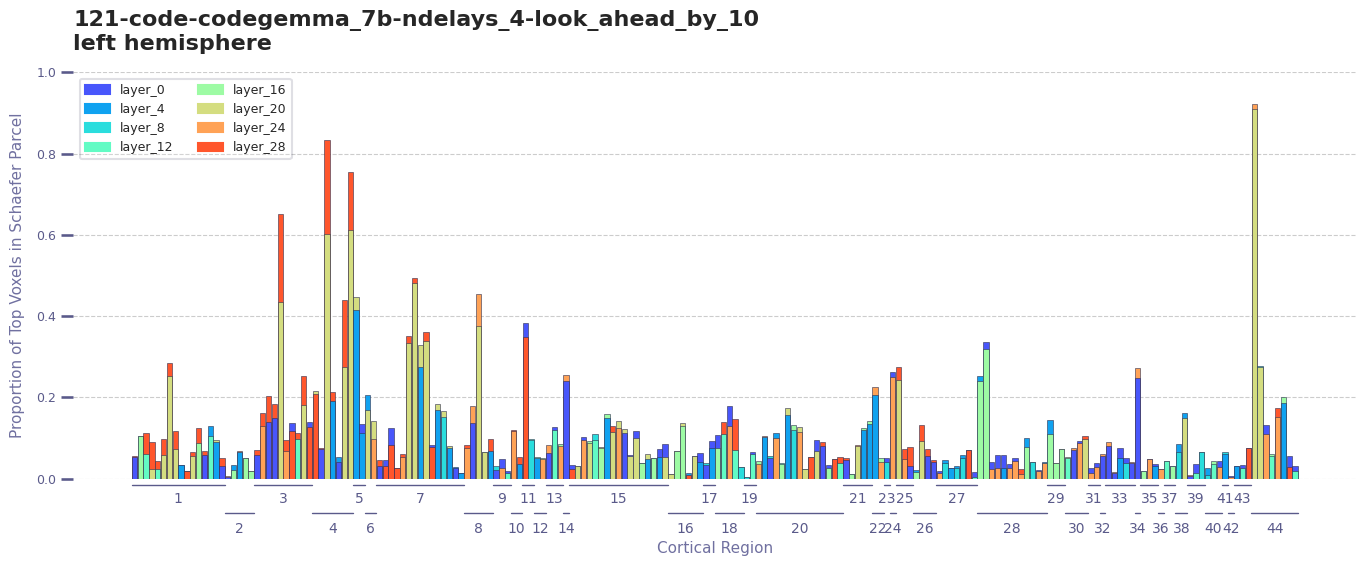

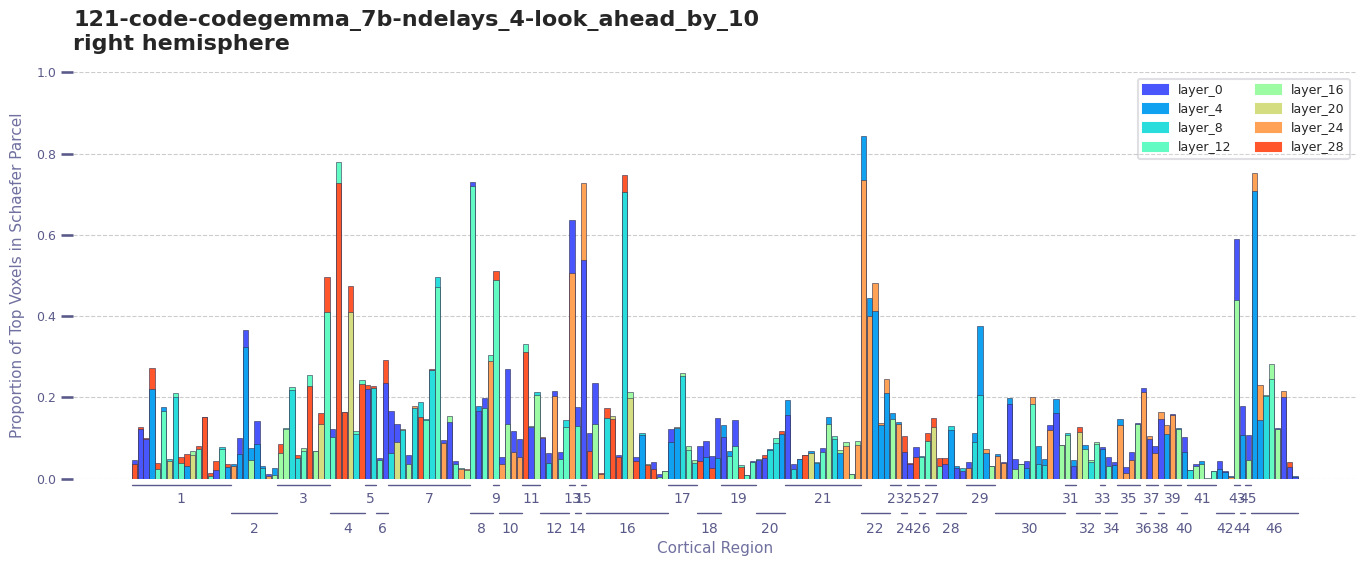

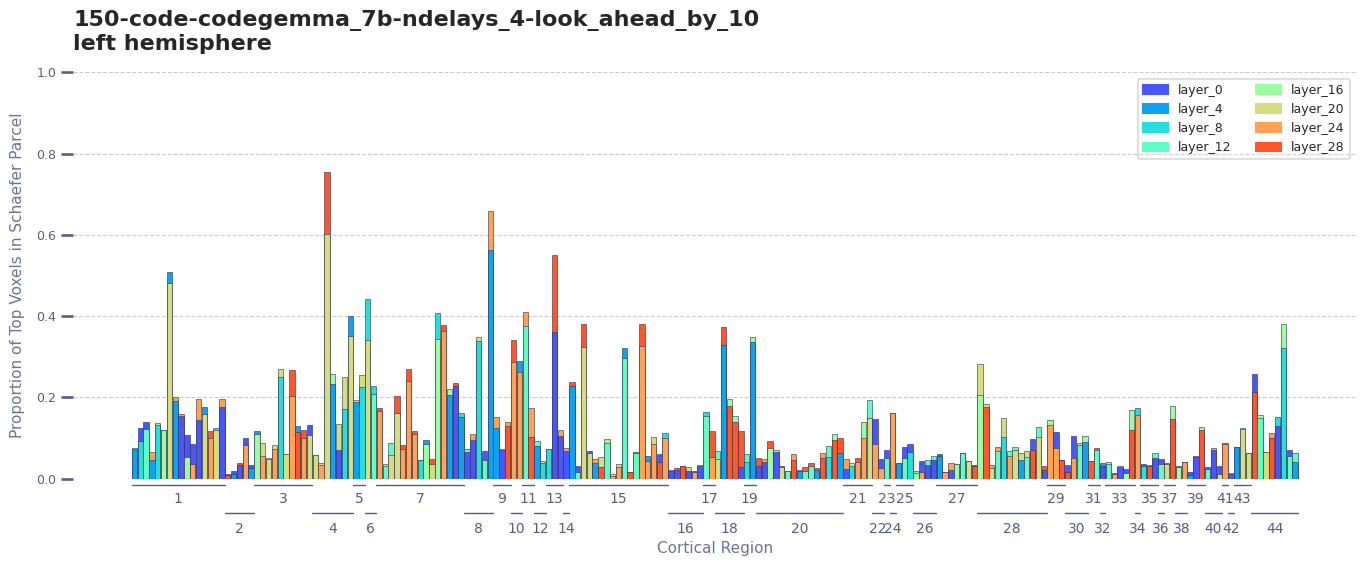

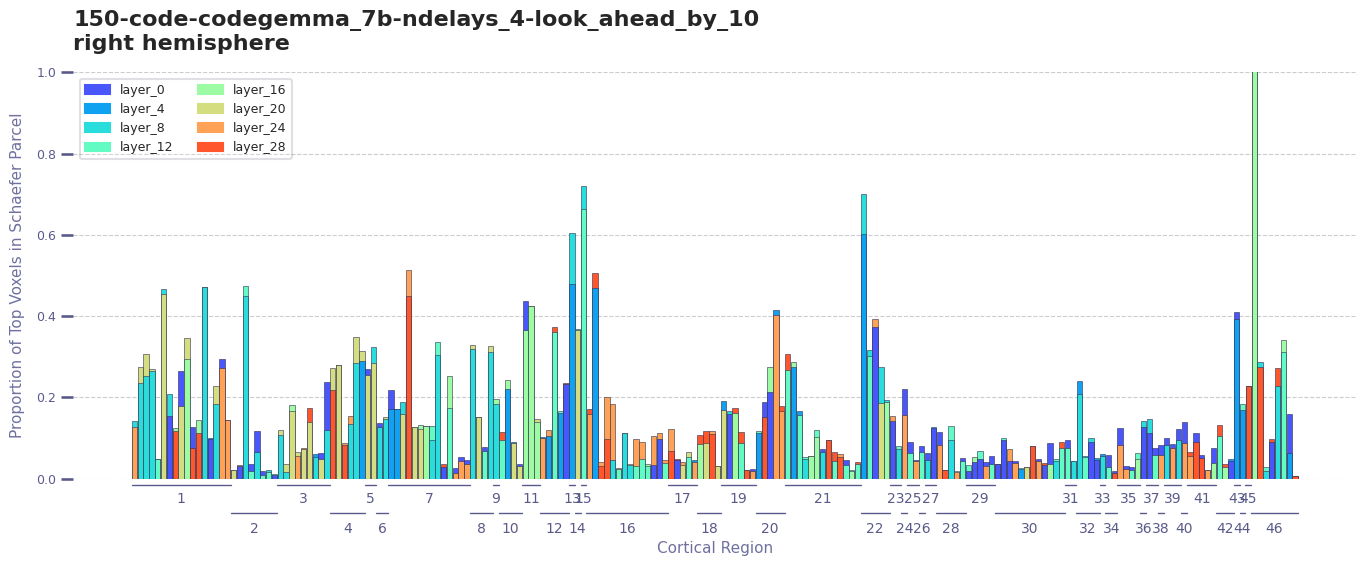

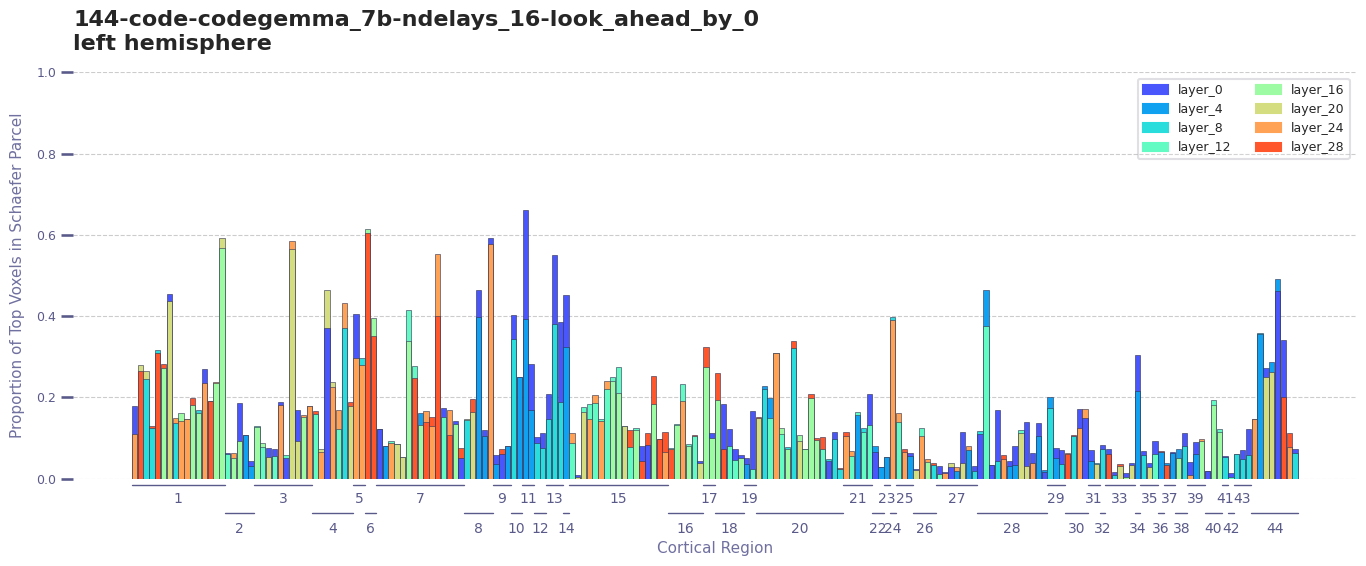

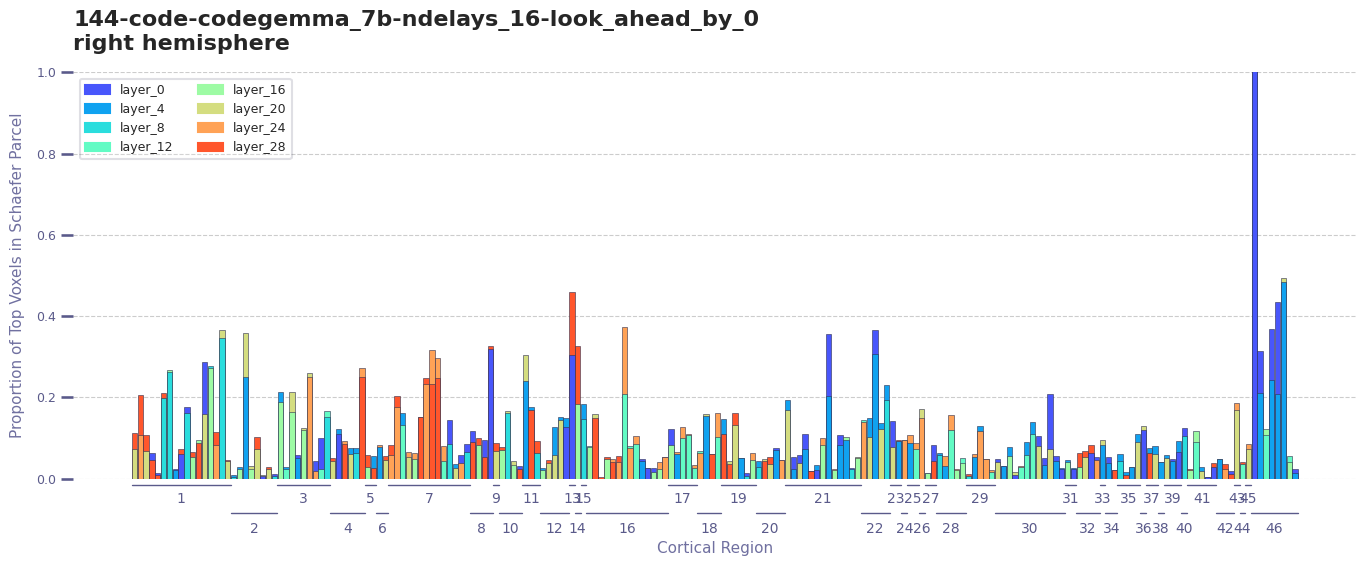

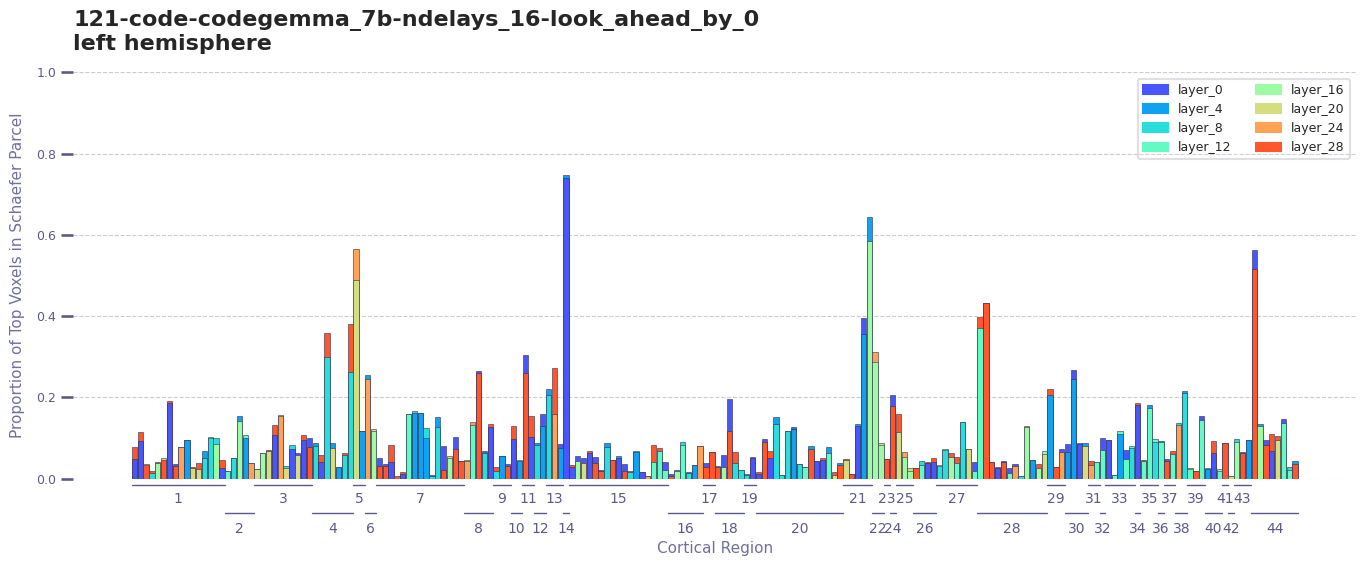

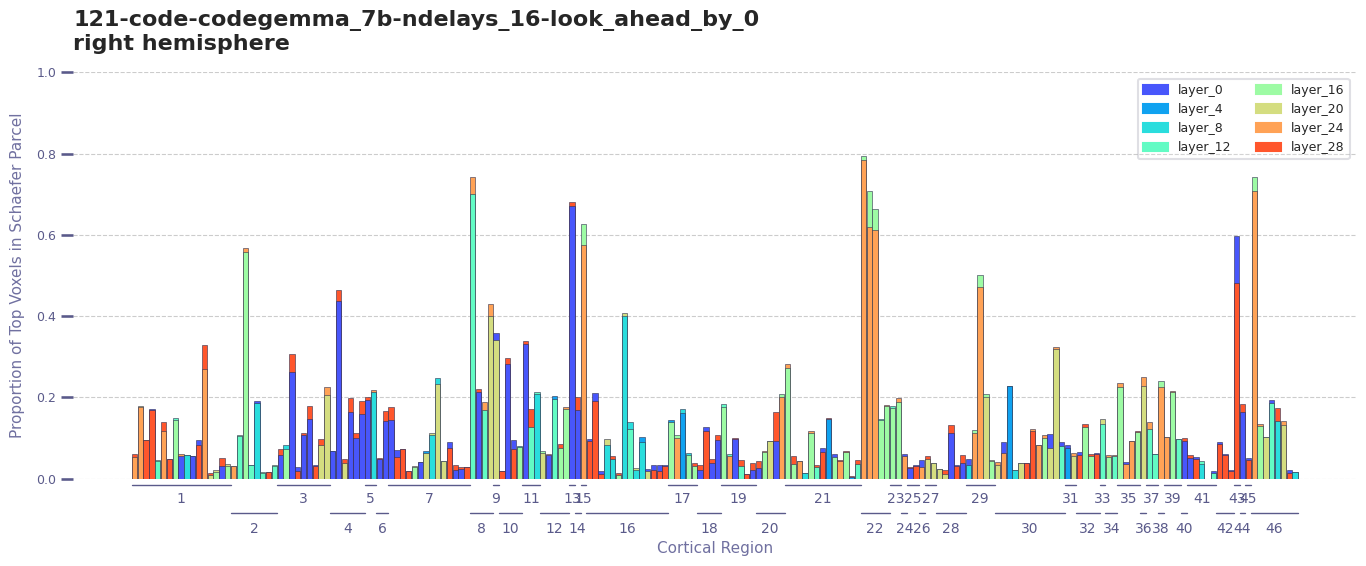

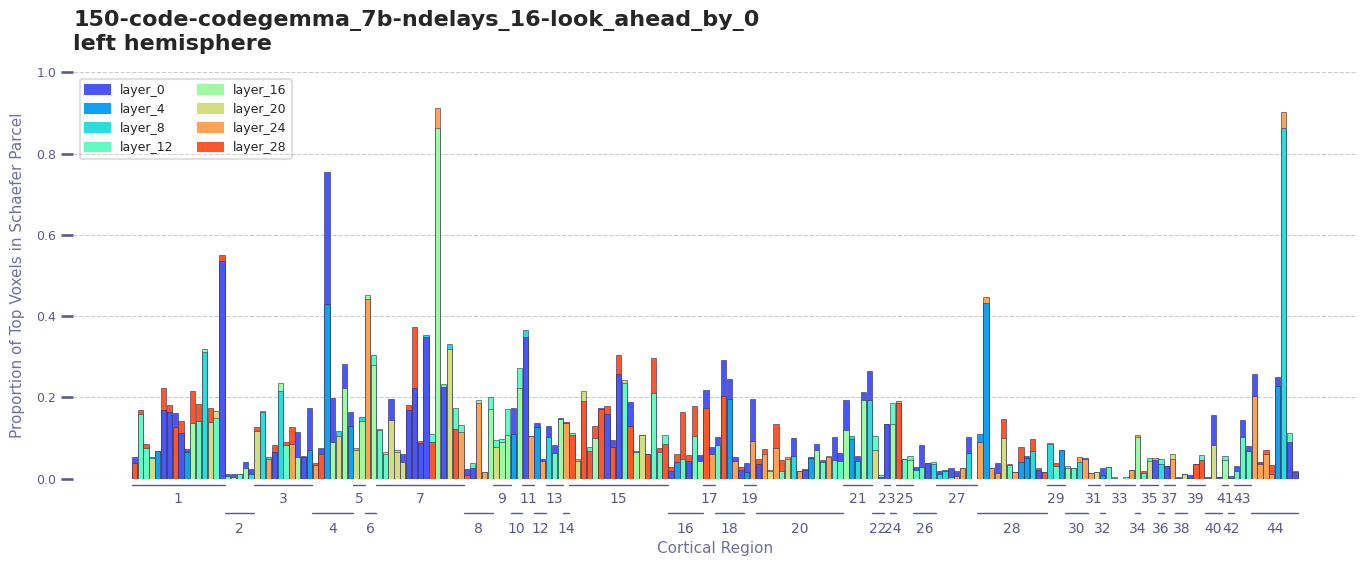

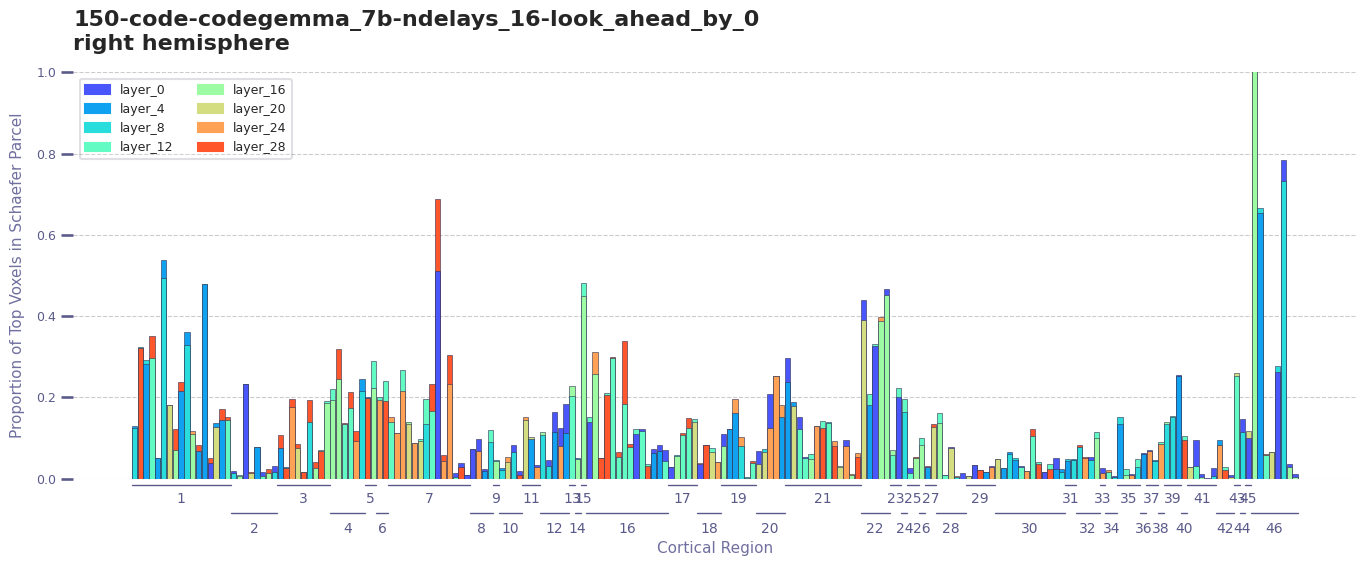

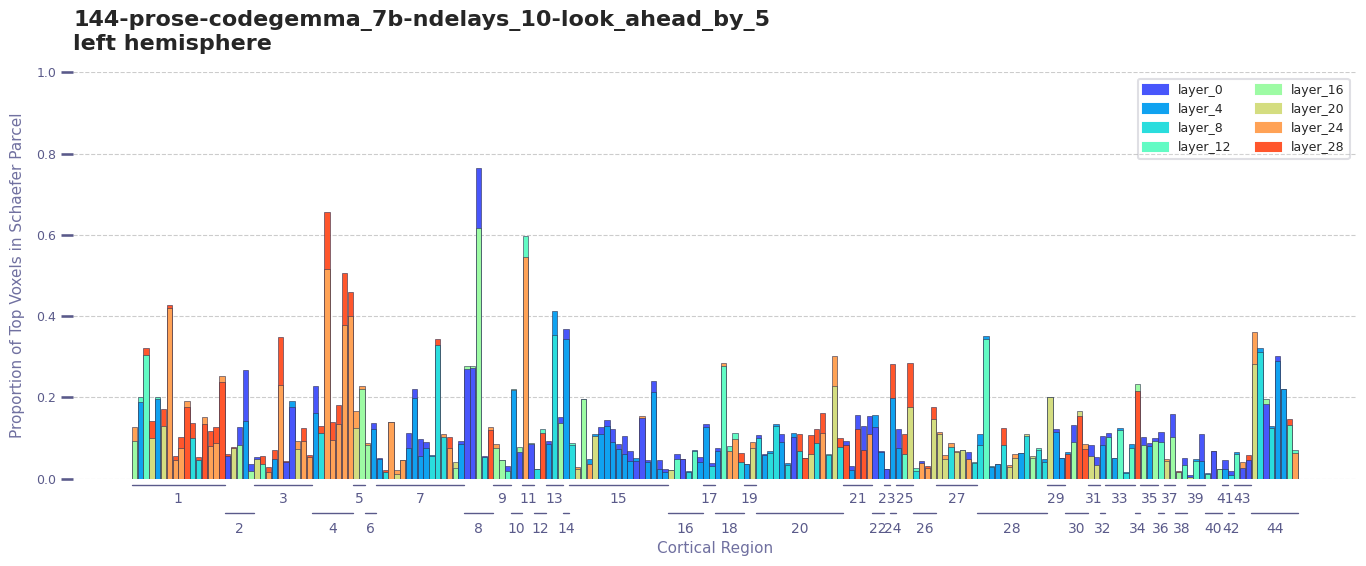

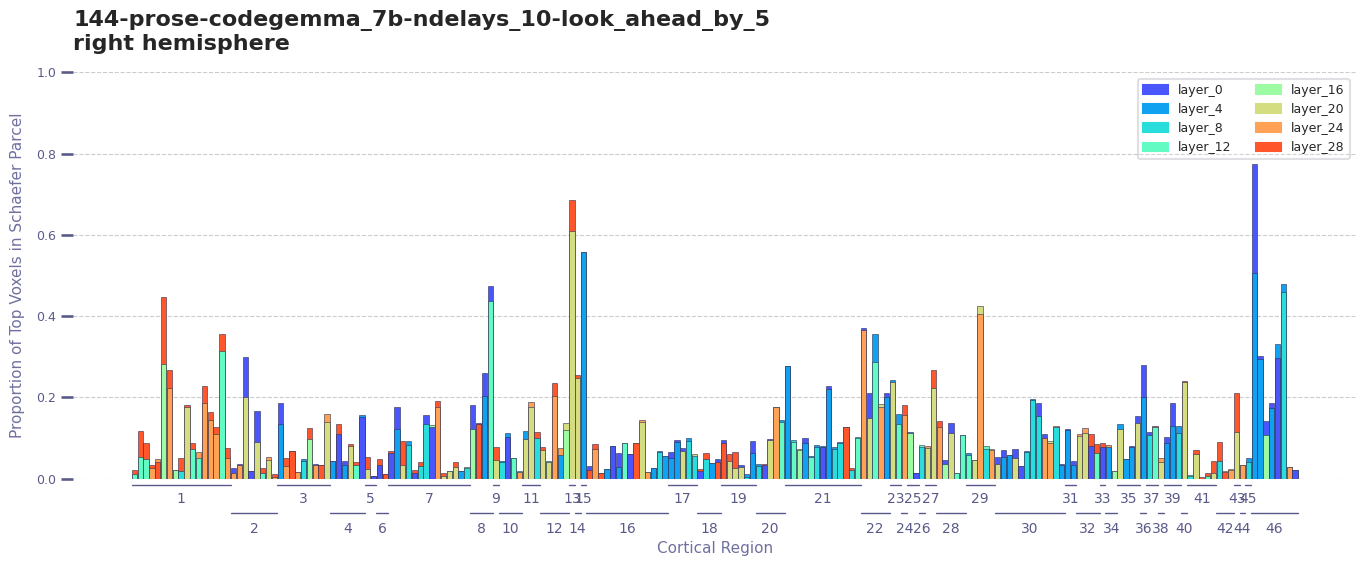

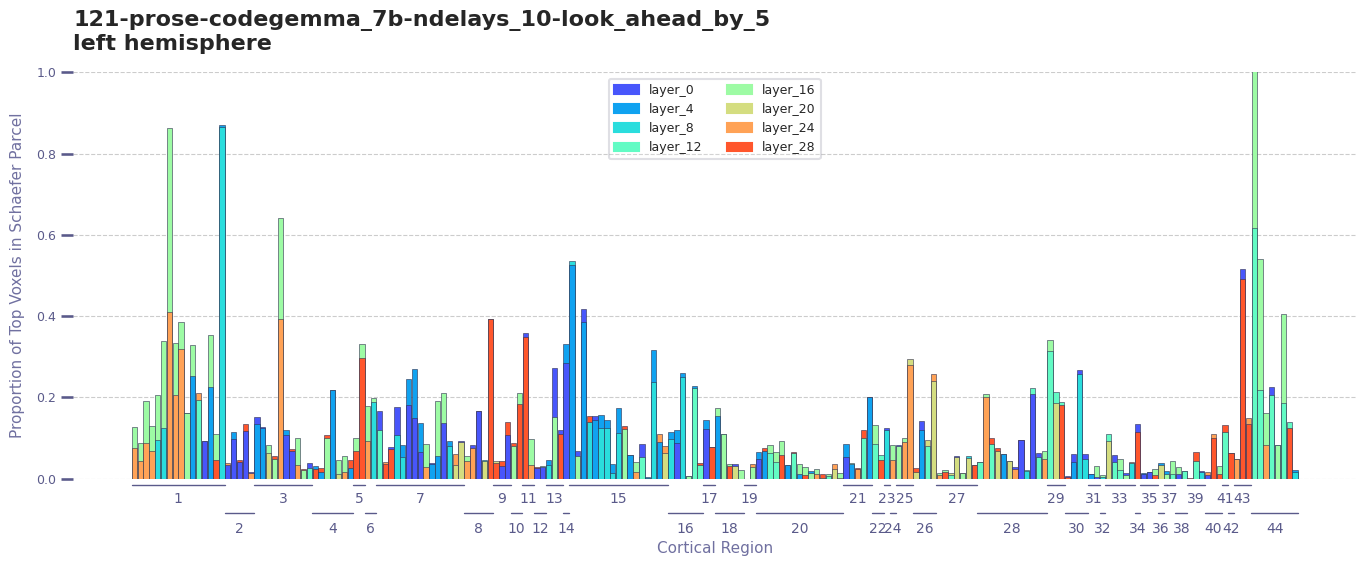

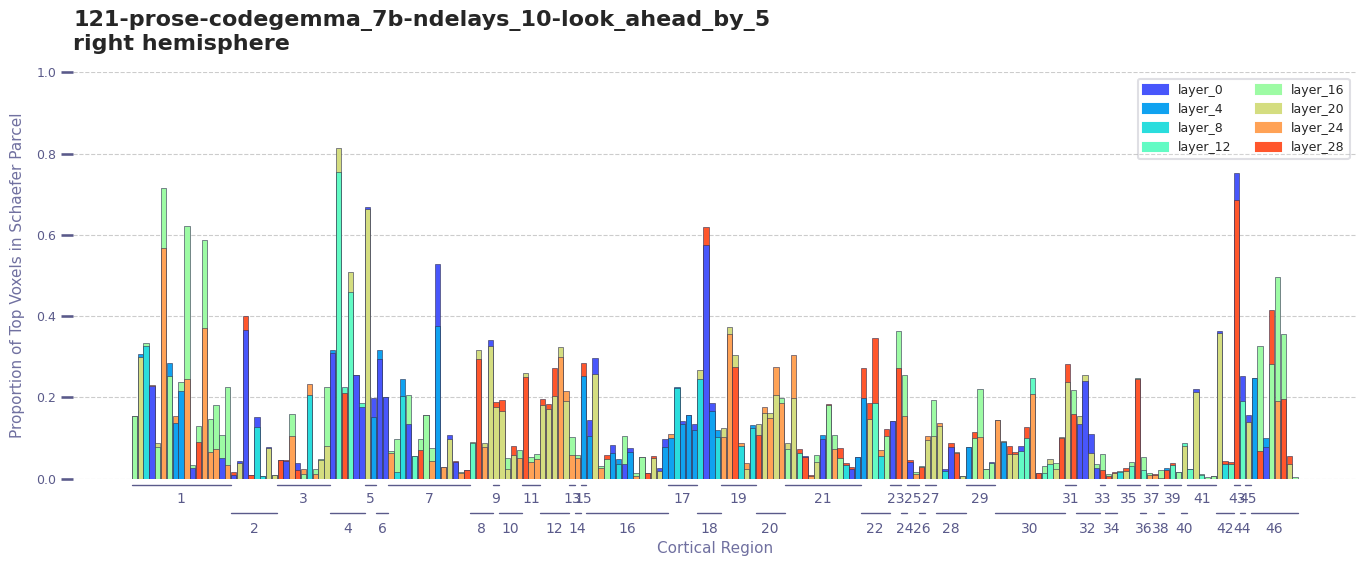

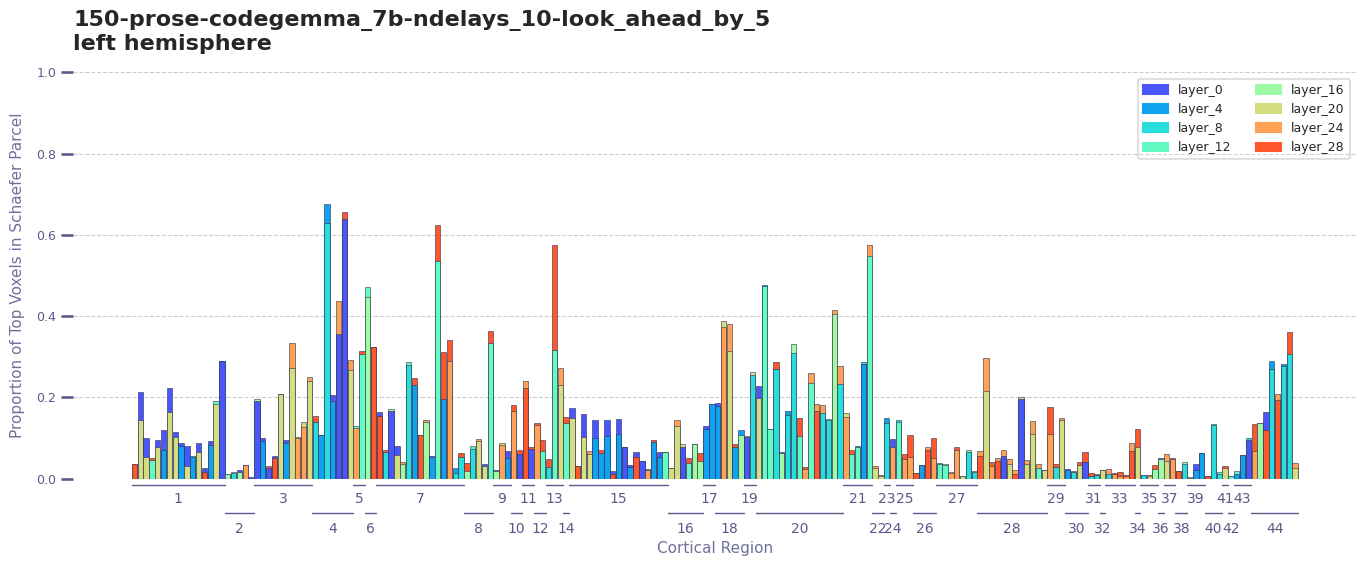

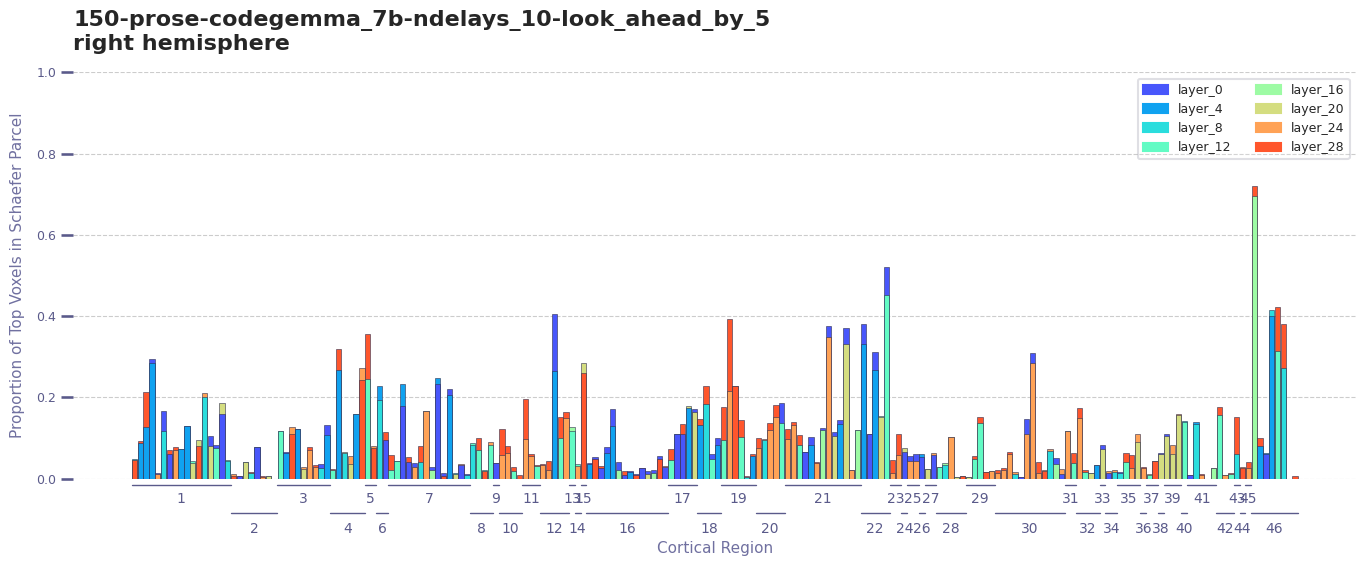

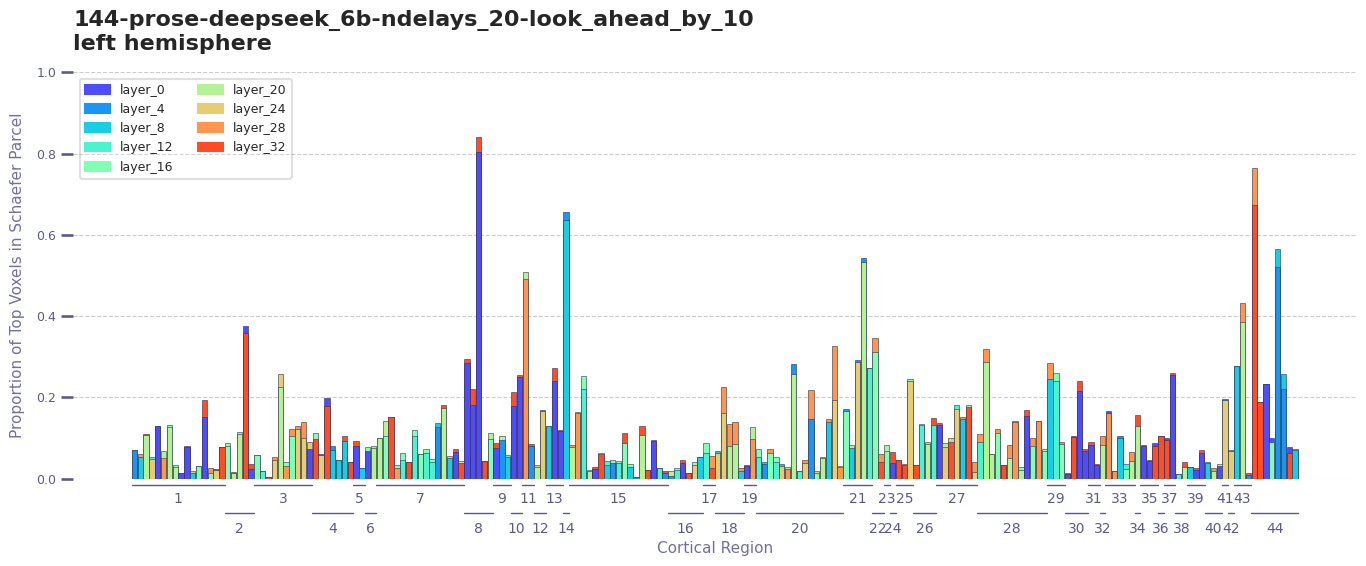

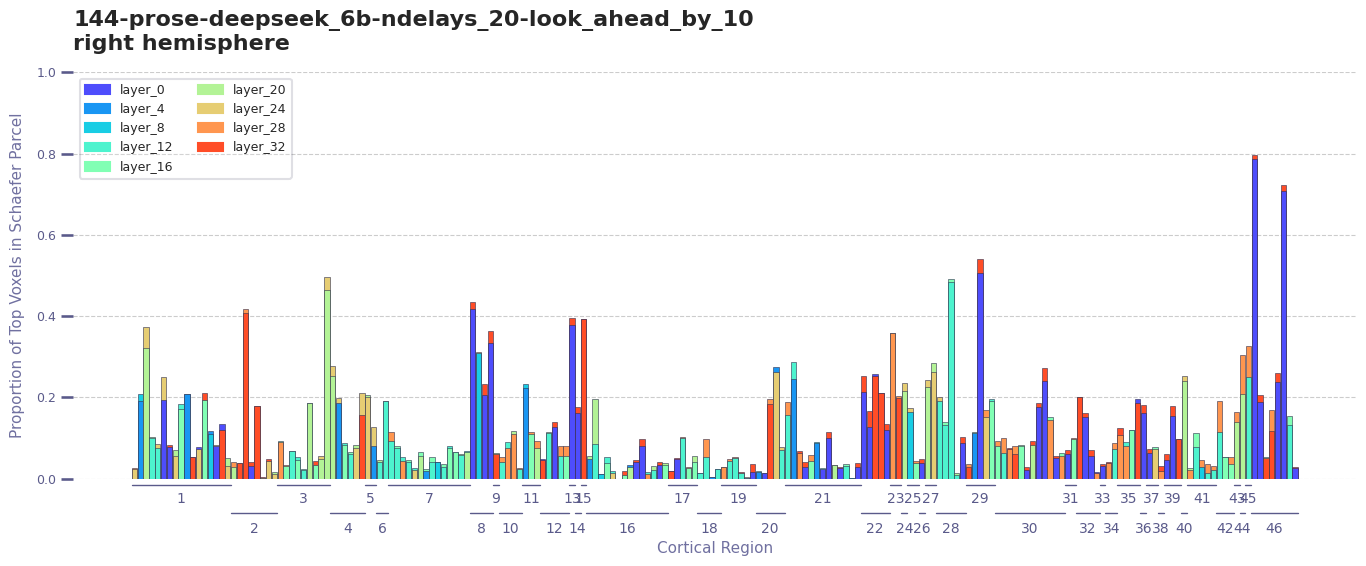

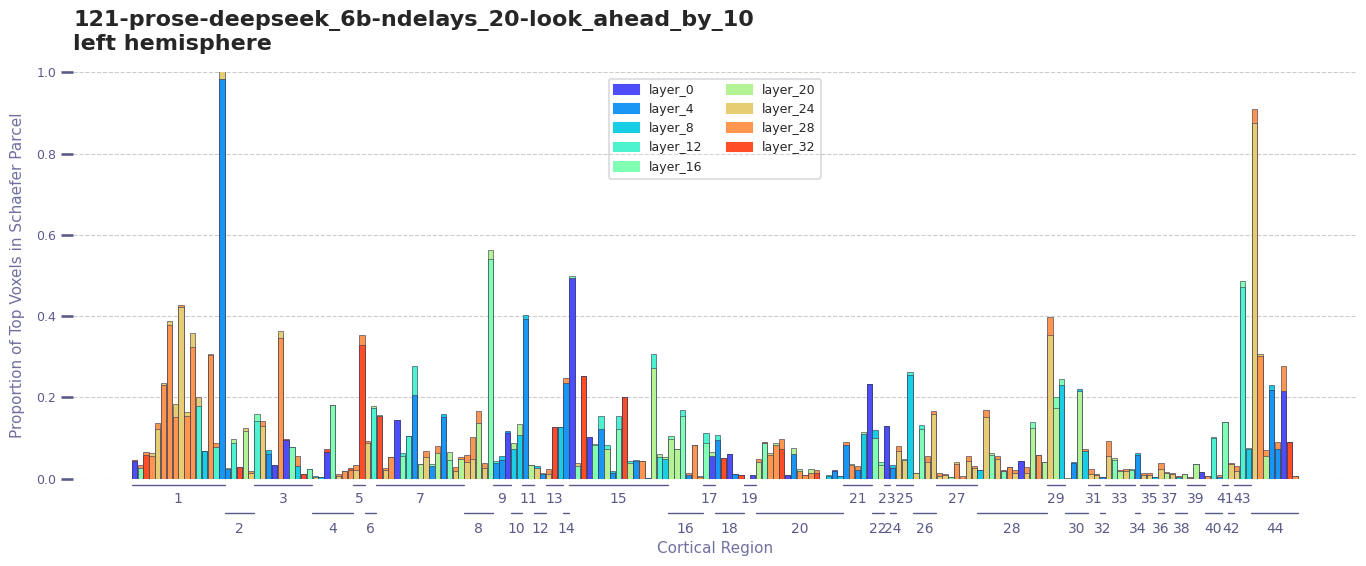

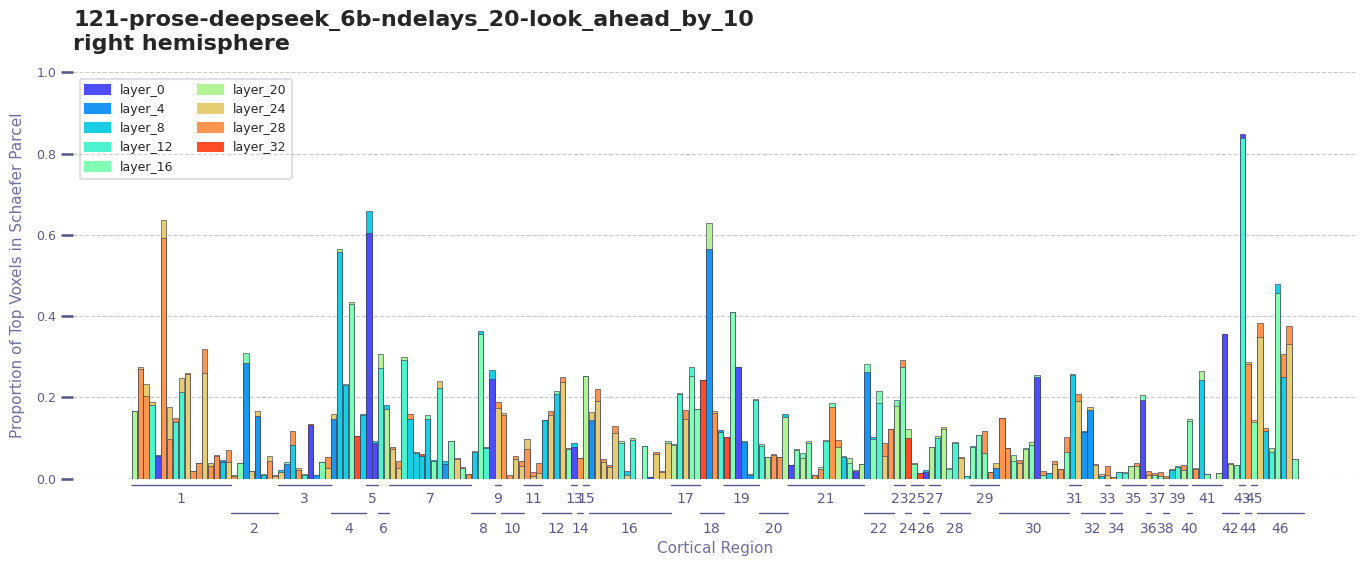

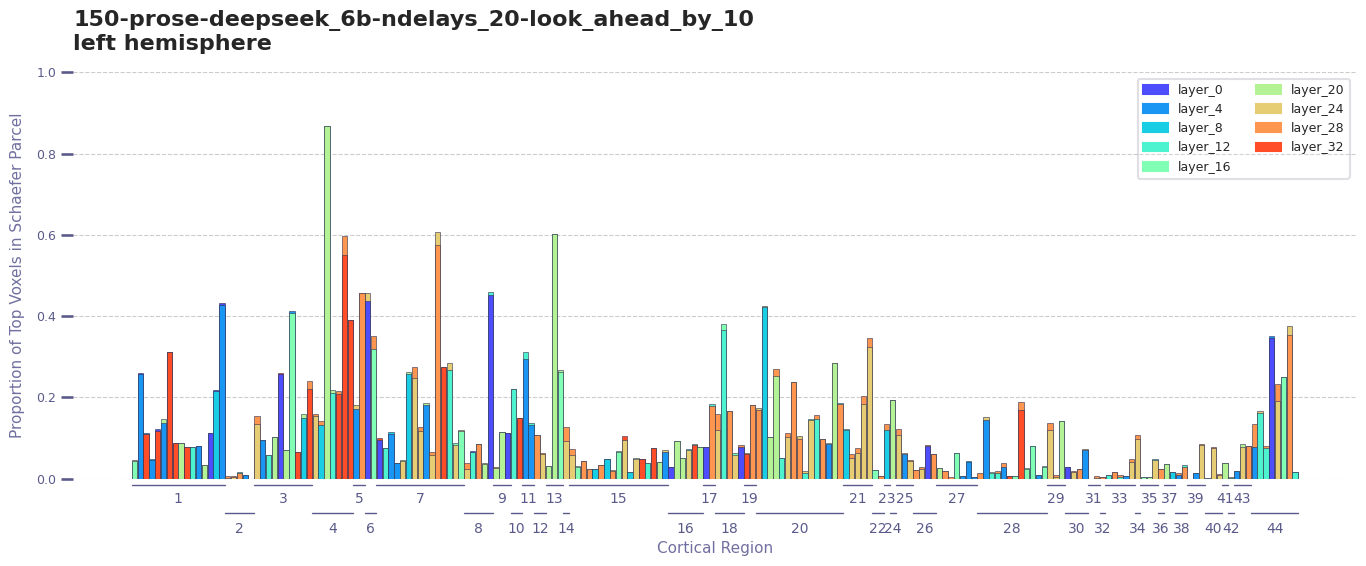

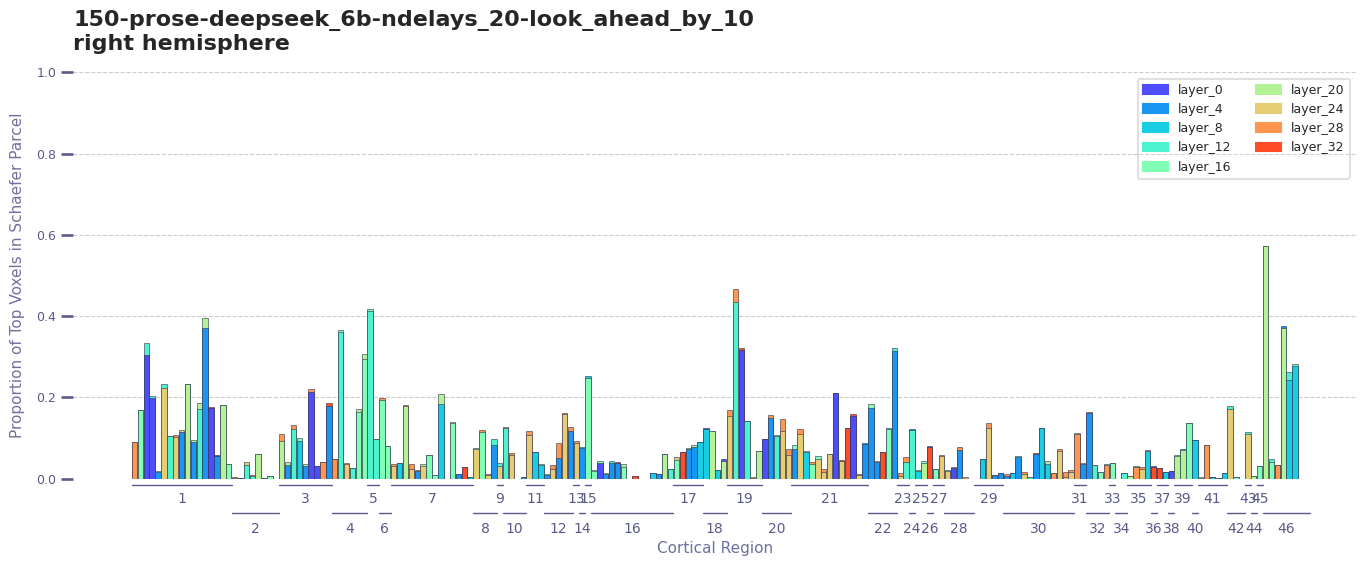

In [13]:
best_models = ['code-deepseek_6b-ndelays_4-look_ahead_by_10', 
               'code-codegemma_7b-ndelays_4-look_ahead_by_10',
               'code-codegemma_7b-ndelays_16-look_ahead_by_0', 
               'prose-codegemma_7b-ndelays_10-look_ahead_by_5', 
               'prose-deepseek_6b-ndelays_20-look_ahead_by_10']

# Maybe a really good participant and a mediocre participant
# Good - 121
# Med. - 150
key_participants = ['144', '121', '150']
for m in best_models:
    # print(m)
    parts = m.split('-')
    task,model,delays,look_ahead = parts[0],parts[1],parts[2],parts[3]

    for vip in key_participants:
        top_parcels = parcel_collection[vip][task][model][delays][look_ahead]

        if not top_parcels:
            print(f"Skipping {vip} {m}: no data")
            continue

        plot_top_parcels(top_parcels, vip, m)

In [14]:
# R code for brains below these graphs
# install.packages("remotes")
# remotes::install_github("LCBC-UiO/ggsegHO")
# library(ggseg)

# ggseg(atlas = hoCort, mapping = aes(fill = region)) +
#   scale_fill_brain("hoCort", package = "ggsegHO") +
#   theme(legend.position = "bottom",
#         legend.text = element_text(size = 6)) +
#   guides(fill = guide_legend(ncol = 2))

In [15]:
from scipy.stats import hypergeom
from statsmodels.stats.multitest import fdrcorrection

def run_hypergeometric(top_parcel_list, parcel_voxel_counts, n_top=10_000):
    """
    Test which Schaefer parcels are significantly enriched among the top voxels.

    Parameters
    ----------
    top_parcel_list   : list of ints — parcel label for each of the top n voxels
    parcel_voxel_counts : dict {parcel_num: total_voxel_count}
    n_top             : int — number of top voxels drawn (default 10k)

    Returns
    -------
    results : list of dicts with keys:
        parcel, observed, expected, p_raw, p_fdr, significant
    """
    N = sum(parcel_voxel_counts.values())  # total cortical voxels
    n = n_top                               # top voxels drawn

    # Count how many top voxels fell in each parcel
    observed_counts = defaultdict(int)
    for p in top_parcel_list:
        observed_counts[p] += 1

    parcels = sorted(parcel_voxel_counts.keys())

    # Compute raw p-values via hypergeometric survival function
    p_raw = []
    for parcel in parcels:
        K = parcel_voxel_counts[parcel]   # total voxels in this parcel
        k = observed_counts.get(parcel, 0)  # observed in top n
        # print(f"K: {K} | k: {k} | N: {N} | n: {n}")
        p = hypergeom.sf(k - 1, N, K, n)   # P(X >= k)
        p_raw.append(p)

    # FDR correction across all parcels
    rejected, p_fdr = fdrcorrection(p_raw, alpha=0.05)

    results = []
    for i, parcel in enumerate(parcels):
        K = parcel_voxel_counts[parcel]
        k = observed_counts.get(parcel, 0)
        expected = (K / N) * n
        results.append({
            'parcel':      parcel,
            'observed':    k,
            'expected':    expected,
            'fold_change': k / expected if expected > 0 else np.nan,
            'p_raw':       p_raw[i],
            'p_fdr':       p_fdr[i],
            'significant': rejected[i],
        })

    return results


# --- Example call (replace with your loop variables) ---
# top_parcel_list = parcel_collection[participant][task][model][delays][look_ahead][layer]
# results = run_hypergeometric(top_parcel_list, parcel_voxel_counts)
# sig = [r for r in results if r['significant']]
# print(f"{len(sig)} / 400 parcels significantly enriched")


def filter_results(results):
    total = 0
    filtered_parcels = []
    fold_changes = []
    for r in results:
        if r['significant']:
            total += 1
            filtered_parcels.append(r['parcel'])
            fold_changes.append(r['fold_change'])
    
    return {'num_sig_parcels' : total, 'enriched_parcels' : filtered_parcels}


In [16]:
# with open("schaefer_parcel_counts.pkl", 'rb') as f:
#     parcel_voxel_counts = pickle.load(f)

In [17]:
participants = os.listdir(filepath)
participant_result_dictionary = nested_dict()
for m in best_models:
    print(m)
    parts = m.split('-')
    task,model,delays,look_ahead = parts[0],parts[1],parts[2],parts[3]
    
    for p in participants:
        # print(p)
        top_parcels = parcel_collection[p][task][model][delays][look_ahead]
        
        if not top_parcels:
            print(f"Skipping {vip} {m}: no data")
            continue
        
        # can iterate through different layers here
        for layer,parcel_list in top_parcels.items():
            # print(layer, p)
            enrichment_results = run_hypergeometric(parcel_list, parcel_voxel_counts)
            significant_results = filter_results(enrichment_results)
            # print(enrichment_results)
            participant_result_dictionary[m][layer][p] = significant_results
            # participant_result_dictionary[m][layer][p] = enrichment_results
    #         break
    #     break
    # break
        # plot_top_parcels(top_parcels, vip, m)

code-deepseek_6b-ndelays_4-look_ahead_by_10
Skipping 150 code-deepseek_6b-ndelays_4-look_ahead_by_10: no data
code-codegemma_7b-ndelays_4-look_ahead_by_10
Skipping 150 code-codegemma_7b-ndelays_4-look_ahead_by_10: no data
code-codegemma_7b-ndelays_16-look_ahead_by_0
Skipping 150 code-codegemma_7b-ndelays_16-look_ahead_by_0: no data
prose-codegemma_7b-ndelays_10-look_ahead_by_5
Skipping 150 prose-codegemma_7b-ndelays_10-look_ahead_by_5: no data
prose-deepseek_6b-ndelays_20-look_ahead_by_10
Skipping 150 prose-deepseek_6b-ndelays_20-look_ahead_by_10: no data


In [18]:
for m,l_p in participant_result_dictionary.items():
    for l,p_results in l_p.items():
        for p, results in p_results.items():
            print(p, m, l, results)

111 code-deepseek_6b-ndelays_4-look_ahead_by_10 layer_32 {'num_sig_parcels': 87, 'enriched_parcels': [6, 8, 9, 14, 15, 17, 18, 19, 23, 24, 27, 31, 42, 52, 58, 59, 63, 64, 70, 71, 74, 75, 76, 77, 79, 80, 81, 82, 83, 84, 85, 87, 89, 90, 91, 98, 102, 103, 113, 119, 120, 132, 136, 139, 140, 143, 144, 149, 150, 159, 166, 175, 179, 182, 185, 189, 204, 206, 208, 209, 210, 213, 215, 218, 221, 223, 226, 227, 234, 247, 277, 278, 280, 282, 285, 286, 288, 302, 304, 309, 325, 327, 328, 334, 367, 380, 383]}
117 code-deepseek_6b-ndelays_4-look_ahead_by_10 layer_32 {'num_sig_parcels': 108, 'enriched_parcels': [8, 17, 23, 25, 29, 30, 31, 32, 33, 37, 40, 42, 43, 44, 46, 47, 51, 52, 57, 58, 59, 60, 61, 63, 64, 65, 66, 67, 68, 70, 71, 74, 76, 78, 79, 80, 81, 82, 83, 84, 85, 88, 89, 90, 91, 93, 94, 95, 105, 110, 113, 119, 127, 128, 129, 131, 132, 133, 135, 136, 137, 144, 145, 151, 154, 159, 161, 162, 163, 164, 171, 172, 175, 182, 185, 188, 189, 229, 230, 256, 261, 264, 266, 267, 268, 269, 270, 274, 280, 28

In [19]:
import json

participant_result_dictionary = json.loads(json.dumps(participant_result_dictionary))

with open('results/participant_parcel_enrichment_results.pkl', 'wb') as f:
    pickle.dump(participant_result_dictionary, f)

In [20]:
### TODO - check regions corresponding to Schaefer parcels